## Loading libraries

In [18]:
import mlflow
import dagshub
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, auc
)
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("✓ All required libraries imported successfully!")


✓ All required libraries imported successfully!


## Initialize DagsHub and MLflow

In [6]:
# Initialize DagsHub with MLflow integration
dagshub.init(
    repo_owner='taqihaider7',
    repo_name='Diabetes-Prediction-DCS-NSU',
    mlflow=True
)

# Set experiment name
experiment_name = "Diabetes-Prediction-Experiments-vscode"
mlflow.set_experiment(experiment_name)

print(f"✓ DagsHub initialized successfully!")
print(f"✓ MLflow Experiment: {experiment_name}")
print(f"✓ Tracking URI: {mlflow.get_tracking_uri()}")
print(f"✓ All experiments and artifacts will be logged to DagsHub")
print(f"✓ Repository: taqihaider7/Diabetes-Prediction-DCS-NSU")

Initialized MLflow to track repo "taqihaider7/Diabetes-Prediction-DCS-NSU"

Repository taqihaider7/Diabetes-Prediction-DCS-NSU initialized!

2025/10/27 15:40:04 INFO mlflow.tracking.fluent: Experiment with name 'Diabetes-Prediction-Experiments-vscode' does not exist. Creating a new experiment.


✓ DagsHub initialized successfully!
✓ MLflow Experiment: Diabetes-Prediction-Experiments-vscode
✓ Tracking URI: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow
✓ All experiments and artifacts will be logged to DagsHub
✓ Repository: taqihaider7/Diabetes-Prediction-DCS-NSU


## Loading Processed Dataset

In [19]:
data = pd.read_csv(r"C:\Users\DELL\Desktop\NSU\3rd_semester\Distributed_computing_system\Diabetes-Prediction\Diabetes-Prediction-DCS-NSU\data\processed_data.csv")
data.head()

,Outcome,N1,N2,N3,N4,N5,N6,N7,N9,N10,...,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,N0,N8,N13,N12,N14
0,1,0,0,0,0,0,0,0,1,1,...,0.665181,0.311604,0.169483,0.468492,1.425995,0.436284,0.144246,-0.561641,1.202461,-0.023905
1,0,0,1,0,1,0,0,1,1,1,...,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672,-0.455696,-0.929227,-0.538026,-0.382029,0.014204
2,1,0,1,0,0,0,0,0,1,1,...,0.327535,0.311604,-1.328478,0.604397,-0.105584,-0.512575,1.734723,-0.421674,0.440289,-0.566853
3,0,1,1,1,1,0,0,1,1,1,...,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549,-0.731491,-0.741294,0.583847,-0.952845,-0.389882
4,1,0,0,0,0,0,0,0,1,1,...,0.665181,0.294758,1.551096,5.484909,-0.020496,1.169312,-1.323886,-1.241345,4.620388,-0.527802


In [20]:
# Def X and Y
X = data.drop(columns='Outcome')
y = data['Outcome']

## Model Training: XGBoost and LightGBM with MLflow Tracking

In [21]:
# Cross-Validation Setup (No Data Scaling)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✓ Cross-validation setup: Stratified 5-Fold")
print(f"✓ X shape: {X.shape}, y shape: {y.shape}")


✓ Cross-validation setup: Stratified 5-Fold
✓ X shape: (768, 24), y shape: (768,)


In [22]:
# ==================== XGBoost Model Training ====================
print("\n" + "="*80)
print("TRAINING XGBOOST MODEL WITH MLflow TRACKING")
print("="*80 + "\n")

# Initialize MLflow run for XGBoost
with mlflow.start_run(run_name="XGBoost-5Fold-CV") as xgb_run:
    
    # XGBoost hyperparameters
    xgb_params = {
        'n_estimators': 100,
        'max_depth': 5,
        'learning_rate': 0.01,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0
    }
    
    # Log hyperparameters
    mlflow.log_params({f"xgb_{k}": v for k, v in xgb_params.items()})
    
    # Store CV results
    xgb_cv_results = {
        'train_accuracy': [],
        'train_precision': [],
        'train_recall': [],
        'train_f1': [],
        'train_roc_auc': [],
        'test_accuracy': [],
        'test_precision': [],
        'test_recall': [],
        'test_f1': [],
        'test_roc_auc': [],
        'fold': []
    }
    
    # 5-Fold Cross-Validation for XGBoost
    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Train XGBoost model
        xgb_model = xgb.XGBClassifier(**xgb_params)
        xgb_model.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = xgb_model.predict(X_train)
        y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]
        y_test_pred = xgb_model.predict(X_test)
        y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics for training set
        train_acc = accuracy_score(y_train, y_train_pred)
        train_prec = precision_score(y_train, y_train_pred, zero_division=0)
        train_rec = recall_score(y_train, y_train_pred, zero_division=0)
        train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
        train_roc = roc_auc_score(y_train, y_train_pred_proba)
        
        # Calculate metrics for test set
        test_acc = accuracy_score(y_test, y_test_pred)
        test_prec = precision_score(y_test, y_test_pred, zero_division=0)
        test_rec = recall_score(y_test, y_test_pred, zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
        test_roc = roc_auc_score(y_test, y_test_pred_proba)
        
        # Manually log each metric to MLflow for this fold
        mlflow.log_metric(f"xgb_fold_{fold}_train_accuracy", train_acc)
        mlflow.log_metric(f"xgb_fold_{fold}_train_precision", train_prec)
        mlflow.log_metric(f"xgb_fold_{fold}_train_recall", train_rec)
        mlflow.log_metric(f"xgb_fold_{fold}_train_f1", train_f1)
        mlflow.log_metric(f"xgb_fold_{fold}_train_roc_auc", train_roc)
        mlflow.log_metric(f"xgb_fold_{fold}_test_accuracy", test_acc)
        mlflow.log_metric(f"xgb_fold_{fold}_test_precision", test_prec)
        mlflow.log_metric(f"xgb_fold_{fold}_test_recall", test_rec)
        mlflow.log_metric(f"xgb_fold_{fold}_test_f1", test_f1)
        mlflow.log_metric(f"xgb_fold_{fold}_test_roc_auc", test_roc)
        
        # Store results
        xgb_cv_results['fold'].append(fold)
        xgb_cv_results['train_accuracy'].append(train_acc)
        xgb_cv_results['train_precision'].append(train_prec)
        xgb_cv_results['train_recall'].append(train_rec)
        xgb_cv_results['train_f1'].append(train_f1)
        xgb_cv_results['train_roc_auc'].append(train_roc)
        xgb_cv_results['test_accuracy'].append(test_acc)
        xgb_cv_results['test_precision'].append(test_prec)
        xgb_cv_results['test_recall'].append(test_rec)
        xgb_cv_results['test_f1'].append(test_f1)
        xgb_cv_results['test_roc_auc'].append(test_roc)
        
        print(f"Fold {fold} - XGBoost:")
        print(f"  Train - Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f}, F1: {train_f1:.4f}, ROC-AUC: {train_roc:.4f}")
        print(f"  Test  - Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Rec: {test_rec:.4f}, F1: {test_f1:.4f}, ROC-AUC: {test_roc:.4f}\n")
        
        fold += 1
    
    # Calculate average metrics
    xgb_avg_metrics = {
        'avg_train_accuracy': np.mean(xgb_cv_results['train_accuracy']),
        'avg_train_precision': np.mean(xgb_cv_results['train_precision']),
        'avg_train_recall': np.mean(xgb_cv_results['train_recall']),
        'avg_train_f1': np.mean(xgb_cv_results['train_f1']),
        'avg_train_roc_auc': np.mean(xgb_cv_results['train_roc_auc']),
        'avg_test_accuracy': np.mean(xgb_cv_results['test_accuracy']),
        'avg_test_precision': np.mean(xgb_cv_results['test_precision']),
        'avg_test_recall': np.mean(xgb_cv_results['test_recall']),
        'avg_test_f1': np.mean(xgb_cv_results['test_f1']),
        'avg_test_roc_auc': np.mean(xgb_cv_results['test_roc_auc']),
        'std_train_accuracy': np.std(xgb_cv_results['train_accuracy']),
        'std_train_precision': np.std(xgb_cv_results['train_precision']),
        'std_train_recall': np.std(xgb_cv_results['train_recall']),
        'std_train_f1': np.std(xgb_cv_results['train_f1']),
        'std_train_roc_auc': np.std(xgb_cv_results['train_roc_auc']),
        'std_test_accuracy': np.std(xgb_cv_results['test_accuracy']),
        'std_test_precision': np.std(xgb_cv_results['test_precision']),
        'std_test_recall': np.std(xgb_cv_results['test_recall']),
        'std_test_f1': np.std(xgb_cv_results['test_f1']),
        'std_test_roc_auc': np.std(xgb_cv_results['test_roc_auc'])
    }
    
    # Manually log each average metric to MLflow
    mlflow.log_metric("xgb_avg_train_accuracy", xgb_avg_metrics['avg_train_accuracy'])
    mlflow.log_metric("xgb_avg_train_precision", xgb_avg_metrics['avg_train_precision'])
    mlflow.log_metric("xgb_avg_train_recall", xgb_avg_metrics['avg_train_recall'])
    mlflow.log_metric("xgb_avg_train_f1", xgb_avg_metrics['avg_train_f1'])
    mlflow.log_metric("xgb_avg_train_roc_auc", xgb_avg_metrics['avg_train_roc_auc'])
    mlflow.log_metric("xgb_avg_test_accuracy", xgb_avg_metrics['avg_test_accuracy'])
    mlflow.log_metric("xgb_avg_test_precision", xgb_avg_metrics['avg_test_precision'])
    mlflow.log_metric("xgb_avg_test_recall", xgb_avg_metrics['avg_test_recall'])
    mlflow.log_metric("xgb_avg_test_f1", xgb_avg_metrics['avg_test_f1'])
    mlflow.log_metric("xgb_avg_test_roc_auc", xgb_avg_metrics['avg_test_roc_auc'])
    
    # Manually log standard deviations
    mlflow.log_metric("xgb_std_train_accuracy", xgb_avg_metrics['std_train_accuracy'])
    mlflow.log_metric("xgb_std_train_precision", xgb_avg_metrics['std_train_precision'])
    mlflow.log_metric("xgb_std_train_recall", xgb_avg_metrics['std_train_recall'])
    mlflow.log_metric("xgb_std_train_f1", xgb_avg_metrics['std_train_f1'])
    mlflow.log_metric("xgb_std_train_roc_auc", xgb_avg_metrics['std_train_roc_auc'])
    mlflow.log_metric("xgb_std_test_accuracy", xgb_avg_metrics['std_test_accuracy'])
    mlflow.log_metric("xgb_std_test_precision", xgb_avg_metrics['std_test_precision'])
    mlflow.log_metric("xgb_std_test_recall", xgb_avg_metrics['std_test_recall'])
    mlflow.log_metric("xgb_std_test_f1", xgb_avg_metrics['std_test_f1'])
    mlflow.log_metric("xgb_std_test_roc_auc", xgb_avg_metrics['std_test_roc_auc'])
    
    print("\nXGBoost - Average Cross-Validation Metrics:")
    print(f"  Test Accuracy:  {xgb_avg_metrics['avg_test_accuracy']:.4f} ± {xgb_avg_metrics['std_test_accuracy']:.4f}")
    print(f"  Test Precision: {xgb_avg_metrics['avg_test_precision']:.4f} ± {xgb_avg_metrics['std_test_precision']:.4f}")
    print(f"  Test Recall:    {xgb_avg_metrics['avg_test_recall']:.4f} ± {xgb_avg_metrics['std_test_recall']:.4f}")
    print(f"  Test F1-Score:  {xgb_avg_metrics['avg_test_f1']:.4f} ± {xgb_avg_metrics['std_test_f1']:.4f}")
    print(f"  Test ROC-AUC:   {xgb_avg_metrics['avg_test_roc_auc']:.4f} ± {xgb_avg_metrics['std_test_roc_auc']:.4f}")
    
    # Log CV results as artifact
    mlflow.log_dict(xgb_cv_results, "xgboost_cv_results.json")
    
    print(f"\n✓ XGBoost run logged to MLflow with Run ID: {xgb_run.info.run_id}")



TRAINING XGBOOST MODEL WITH MLflow TRACKING

Fold 1 - XGBoost:
  Train - Acc: 0.9381, Prec: 0.9889, Rec: 0.8318, F1: 0.9036, ROC-AUC: 0.9924
  Test  - Acc: 0.8442, Prec: 0.8125, Rec: 0.7222, F1: 0.7647, ROC-AUC: 0.9309

Fold 1 - XGBoost:
  Train - Acc: 0.9381, Prec: 0.9889, Rec: 0.8318, F1: 0.9036, ROC-AUC: 0.9924
  Test  - Acc: 0.8442, Prec: 0.8125, Rec: 0.7222, F1: 0.7647, ROC-AUC: 0.9309

Fold 2 - XGBoost:
  Train - Acc: 0.9397, Prec: 0.9683, Rec: 0.8551, F1: 0.9082, ROC-AUC: 0.9889
  Test  - Acc: 0.8506, Prec: 0.8780, Rec: 0.6667, F1: 0.7579, ROC-AUC: 0.9478

Fold 2 - XGBoost:
  Train - Acc: 0.9397, Prec: 0.9683, Rec: 0.8551, F1: 0.9082, ROC-AUC: 0.9889
  Test  - Acc: 0.8506, Prec: 0.8780, Rec: 0.6667, F1: 0.7579, ROC-AUC: 0.9478

Fold 3 - XGBoost:
  Train - Acc: 0.9349, Prec: 0.9677, Rec: 0.8411, F1: 0.9000, ROC-AUC: 0.9911
  Test  - Acc: 0.8506, Prec: 0.8298, Rec: 0.7222, F1: 0.7723, ROC-AUC: 0.9372

Fold 3 - XGBoost:
  Train - Acc: 0.9349, Prec: 0.9677, Rec: 0.8411, F1: 0.9000,

In [23]:
# ==================== LightGBM Model Training ====================
print("\n" + "="*80)
print("TRAINING LIGHTGBM MODEL WITH MLflow TRACKING")
print("="*80 + "\n")

# Initialize MLflow run for LightGBM
with mlflow.start_run(run_name="LightGBM-5Fold-CV") as lgb_run:
    
    # LightGBM hyperparameters
    lgb_params = {
        'num_leaves': 31,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'max_depth': 5,
        'min_data_in_leaf': 20,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'random_state': 42,
        'verbose': -1
    }
    
    # Log hyperparameters
    mlflow.log_params({f"lgb_{k}": v for k, v in lgb_params.items()})
    
    # Store CV results
    lgb_cv_results = {
        'train_accuracy': [],
        'train_precision': [],
        'train_recall': [],
        'train_f1': [],
        'train_roc_auc': [],
        'test_accuracy': [],
        'test_precision': [],
        'test_recall': [],
        'test_f1': [],
        'test_roc_auc': [],
        'fold': []
    }
    
    # 5-Fold Cross-Validation for LightGBM
    fold = 1
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Train LightGBM model
        lgb_model = lgb.LGBMClassifier(**lgb_params)
        lgb_model.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = lgb_model.predict(X_train)
        y_train_pred_proba = lgb_model.predict_proba(X_train)[:, 1]
        y_test_pred = lgb_model.predict(X_test)
        y_test_pred_proba = lgb_model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics for training set
        train_acc = accuracy_score(y_train, y_train_pred)
        train_prec = precision_score(y_train, y_train_pred, zero_division=0)
        train_rec = recall_score(y_train, y_train_pred, zero_division=0)
        train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
        train_roc = roc_auc_score(y_train, y_train_pred_proba)
        
        # Calculate metrics for test set
        test_acc = accuracy_score(y_test, y_test_pred)
        test_prec = precision_score(y_test, y_test_pred, zero_division=0)
        test_rec = recall_score(y_test, y_test_pred, zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
        test_roc = roc_auc_score(y_test, y_test_pred_proba)
        
        # Manually log each metric to MLflow for this fold
        mlflow.log_metric(f"lgb_fold_{fold}_train_accuracy", train_acc)
        mlflow.log_metric(f"lgb_fold_{fold}_train_precision", train_prec)
        mlflow.log_metric(f"lgb_fold_{fold}_train_recall", train_rec)
        mlflow.log_metric(f"lgb_fold_{fold}_train_f1", train_f1)
        mlflow.log_metric(f"lgb_fold_{fold}_train_roc_auc", train_roc)
        mlflow.log_metric(f"lgb_fold_{fold}_test_accuracy", test_acc)
        mlflow.log_metric(f"lgb_fold_{fold}_test_precision", test_prec)
        mlflow.log_metric(f"lgb_fold_{fold}_test_recall", test_rec)
        mlflow.log_metric(f"lgb_fold_{fold}_test_f1", test_f1)
        mlflow.log_metric(f"lgb_fold_{fold}_test_roc_auc", test_roc)
        
        # Store results
        lgb_cv_results['fold'].append(fold)
        lgb_cv_results['train_accuracy'].append(train_acc)
        lgb_cv_results['train_precision'].append(train_prec)
        lgb_cv_results['train_recall'].append(train_rec)
        lgb_cv_results['train_f1'].append(train_f1)
        lgb_cv_results['train_roc_auc'].append(train_roc)
        lgb_cv_results['test_accuracy'].append(test_acc)
        lgb_cv_results['test_precision'].append(test_prec)
        lgb_cv_results['test_recall'].append(test_rec)
        lgb_cv_results['test_f1'].append(test_f1)
        lgb_cv_results['test_roc_auc'].append(test_roc)
        
        print(f"Fold {fold} - LightGBM:")
        print(f"  Train - Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f}, F1: {train_f1:.4f}, ROC-AUC: {train_roc:.4f}")
        print(f"  Test  - Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Rec: {test_rec:.4f}, F1: {test_f1:.4f}, ROC-AUC: {test_roc:.4f}\n")
        
        fold += 1
    
    # Calculate average metrics
    lgb_avg_metrics = {
        'avg_train_accuracy': np.mean(lgb_cv_results['train_accuracy']),
        'avg_train_precision': np.mean(lgb_cv_results['train_precision']),
        'avg_train_recall': np.mean(lgb_cv_results['train_recall']),
        'avg_train_f1': np.mean(lgb_cv_results['train_f1']),
        'avg_train_roc_auc': np.mean(lgb_cv_results['train_roc_auc']),
        'avg_test_accuracy': np.mean(lgb_cv_results['test_accuracy']),
        'avg_test_precision': np.mean(lgb_cv_results['test_precision']),
        'avg_test_recall': np.mean(lgb_cv_results['test_recall']),
        'avg_test_f1': np.mean(lgb_cv_results['test_f1']),
        'avg_test_roc_auc': np.mean(lgb_cv_results['test_roc_auc']),
        'std_train_accuracy': np.std(lgb_cv_results['train_accuracy']),
        'std_train_precision': np.std(lgb_cv_results['train_precision']),
        'std_train_recall': np.std(lgb_cv_results['train_recall']),
        'std_train_f1': np.std(lgb_cv_results['train_f1']),
        'std_train_roc_auc': np.std(lgb_cv_results['train_roc_auc']),
        'std_test_accuracy': np.std(lgb_cv_results['test_accuracy']),
        'std_test_precision': np.std(lgb_cv_results['test_precision']),
        'std_test_recall': np.std(lgb_cv_results['test_recall']),
        'std_test_f1': np.std(lgb_cv_results['test_f1']),
        'std_test_roc_auc': np.std(lgb_cv_results['test_roc_auc'])
    }
    
    # Manually log each average metric to MLflow
    mlflow.log_metric("lgb_avg_train_accuracy", lgb_avg_metrics['avg_train_accuracy'])
    mlflow.log_metric("lgb_avg_train_precision", lgb_avg_metrics['avg_train_precision'])
    mlflow.log_metric("lgb_avg_train_recall", lgb_avg_metrics['avg_train_recall'])
    mlflow.log_metric("lgb_avg_train_f1", lgb_avg_metrics['avg_train_f1'])
    mlflow.log_metric("lgb_avg_train_roc_auc", lgb_avg_metrics['avg_train_roc_auc'])
    mlflow.log_metric("lgb_avg_test_accuracy", lgb_avg_metrics['avg_test_accuracy'])
    mlflow.log_metric("lgb_avg_test_precision", lgb_avg_metrics['avg_test_precision'])
    mlflow.log_metric("lgb_avg_test_recall", lgb_avg_metrics['avg_test_recall'])
    mlflow.log_metric("lgb_avg_test_f1", lgb_avg_metrics['avg_test_f1'])
    mlflow.log_metric("lgb_avg_test_roc_auc", lgb_avg_metrics['avg_test_roc_auc'])
    
    # Manually log standard deviations
    mlflow.log_metric("lgb_std_train_accuracy", lgb_avg_metrics['std_train_accuracy'])
    mlflow.log_metric("lgb_std_train_precision", lgb_avg_metrics['std_train_precision'])
    mlflow.log_metric("lgb_std_train_recall", lgb_avg_metrics['std_train_recall'])
    mlflow.log_metric("lgb_std_train_f1", lgb_avg_metrics['std_train_f1'])
    mlflow.log_metric("lgb_std_train_roc_auc", lgb_avg_metrics['std_train_roc_auc'])
    mlflow.log_metric("lgb_std_test_accuracy", lgb_avg_metrics['std_test_accuracy'])
    mlflow.log_metric("lgb_std_test_precision", lgb_avg_metrics['std_test_precision'])
    mlflow.log_metric("lgb_std_test_recall", lgb_avg_metrics['std_test_recall'])
    mlflow.log_metric("lgb_std_test_f1", lgb_avg_metrics['std_test_f1'])
    mlflow.log_metric("lgb_std_test_roc_auc", lgb_avg_metrics['std_test_roc_auc'])
    
    print("\nLightGBM - Average Cross-Validation Metrics:")
    print(f"  Test Accuracy:  {lgb_avg_metrics['avg_test_accuracy']:.4f} ± {lgb_avg_metrics['std_test_accuracy']:.4f}")
    print(f"  Test Precision: {lgb_avg_metrics['avg_test_precision']:.4f} ± {lgb_avg_metrics['std_test_precision']:.4f}")
    print(f"  Test Recall:    {lgb_avg_metrics['avg_test_recall']:.4f} ± {lgb_avg_metrics['std_test_recall']:.4f}")
    print(f"  Test F1-Score:  {lgb_avg_metrics['avg_test_f1']:.4f} ± {lgb_avg_metrics['std_test_f1']:.4f}")
    print(f"  Test ROC-AUC:   {lgb_avg_metrics['avg_test_roc_auc']:.4f} ± {lgb_avg_metrics['std_test_roc_auc']:.4f}")
    
    # Log CV results as artifact
    mlflow.log_dict(lgb_cv_results, "lightgbm_cv_results.json")
    
    print(f"\n✓ LightGBM run logged to MLflow with Run ID: {lgb_run.info.run_id}")



TRAINING LIGHTGBM MODEL WITH MLflow TRACKING

Fold 1 - LightGBM:
  Train - Acc: 0.9984, Prec: 1.0000, Rec: 0.9953, F1: 0.9977, ROC-AUC: 1.0000
  Test  - Acc: 0.8571, Prec: 0.7963, Rec: 0.7963, F1: 0.7963, ROC-AUC: 0.9220

Fold 1 - LightGBM:
  Train - Acc: 0.9984, Prec: 1.0000, Rec: 0.9953, F1: 0.9977, ROC-AUC: 1.0000
  Test  - Acc: 0.8571, Prec: 0.7963, Rec: 0.7963, F1: 0.7963, ROC-AUC: 0.9220

Fold 2 - LightGBM:
  Train - Acc: 0.9984, Prec: 0.9953, Rec: 1.0000, F1: 0.9977, ROC-AUC: 1.0000
  Test  - Acc: 0.8766, Prec: 0.8571, Rec: 0.7778, F1: 0.8155, ROC-AUC: 0.9522

Fold 2 - LightGBM:
  Train - Acc: 0.9984, Prec: 0.9953, Rec: 1.0000, F1: 0.9977, ROC-AUC: 1.0000
  Test  - Acc: 0.8766, Prec: 0.8571, Rec: 0.7778, F1: 0.8155, ROC-AUC: 0.9522

Fold 3 - LightGBM:
  Train - Acc: 1.0000, Prec: 1.0000, Rec: 1.0000, F1: 1.0000, ROC-AUC: 1.0000
  Test  - Acc: 0.8442, Prec: 0.7778, Rec: 0.7778, F1: 0.7778, ROC-AUC: 0.9228

Fold 3 - LightGBM:
  Train - Acc: 1.0000, Prec: 1.0000, Rec: 1.0000, F1: 

## Model Comparison and Detailed Evaluation

In [24]:
# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'XGBoost (Mean ± Std)': [
        f"{xgb_avg_metrics['avg_test_accuracy']:.4f} ± {xgb_avg_metrics['std_test_accuracy']:.4f}",
        f"{xgb_avg_metrics['avg_test_precision']:.4f} ± {xgb_avg_metrics['std_test_precision']:.4f}",
        f"{xgb_avg_metrics['avg_test_recall']:.4f} ± {xgb_avg_metrics['std_test_recall']:.4f}",
        f"{xgb_avg_metrics['avg_test_f1']:.4f} ± {xgb_avg_metrics['std_test_f1']:.4f}",
        f"{xgb_avg_metrics['avg_test_roc_auc']:.4f} ± {xgb_avg_metrics['std_test_roc_auc']:.4f}"
    ],
    'LightGBM (Mean ± Std)': [
        f"{lgb_avg_metrics['avg_test_accuracy']:.4f} ± {lgb_avg_metrics['std_test_accuracy']:.4f}",
        f"{lgb_avg_metrics['avg_test_precision']:.4f} ± {lgb_avg_metrics['std_test_precision']:.4f}",
        f"{lgb_avg_metrics['avg_test_recall']:.4f} ± {lgb_avg_metrics['std_test_recall']:.4f}",
        f"{lgb_avg_metrics['avg_test_f1']:.4f} ± {lgb_avg_metrics['std_test_f1']:.4f}",
        f"{lgb_avg_metrics['avg_test_roc_auc']:.4f} ± {lgb_avg_metrics['std_test_roc_auc']:.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("MODEL COMPARISON - CLASSIFICATION METRICS")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Log comparison metrics with MLflow
with mlflow.start_run(run_name="Models-Comparison") as comparison_run:
    # Log XGBoost metrics
    mlflow.log_metric("comparison_xgb_test_accuracy", xgb_avg_metrics['avg_test_accuracy'])
    mlflow.log_metric("comparison_xgb_test_precision", xgb_avg_metrics['avg_test_precision'])
    mlflow.log_metric("comparison_xgb_test_recall", xgb_avg_metrics['avg_test_recall'])
    mlflow.log_metric("comparison_xgb_test_f1", xgb_avg_metrics['avg_test_f1'])
    mlflow.log_metric("comparison_xgb_test_roc_auc", xgb_avg_metrics['avg_test_roc_auc'])
    
    # Log LightGBM metrics
    mlflow.log_metric("comparison_lgb_test_accuracy", lgb_avg_metrics['avg_test_accuracy'])
    mlflow.log_metric("comparison_lgb_test_precision", lgb_avg_metrics['avg_test_precision'])
    mlflow.log_metric("comparison_lgb_test_recall", lgb_avg_metrics['avg_test_recall'])
    mlflow.log_metric("comparison_lgb_test_f1", lgb_avg_metrics['avg_test_f1'])
    mlflow.log_metric("comparison_lgb_test_roc_auc", lgb_avg_metrics['avg_test_roc_auc'])
    
    # Log comparison dict
    mlflow.log_dict({
        'xgboost_metrics': xgb_avg_metrics,
        'lightgbm_metrics': lgb_avg_metrics
    }, "models_comparison.json")
    
    print(f"\n✓ Comparison metrics logged to MLflow with Run ID: {comparison_run.info.run_id}")



MODEL COMPARISON - CLASSIFICATION METRICS
   Metric XGBoost (Mean ± Std) LightGBM (Mean ± Std)
 Accuracy      0.8712 ± 0.0314       0.8790 ± 0.0275
Precision      0.8730 ± 0.0466       0.8333 ± 0.0386
   Recall      0.7392 ± 0.0599       0.8175 ± 0.0480
 F1-Score      0.7997 ± 0.0495       0.8249 ± 0.0392
  ROC-AUC      0.9478 ± 0.0125       0.9437 ± 0.0178

✓ Comparison metrics logged to MLflow with Run ID: 857086fb32404207b6cd2290c04bac4d

✓ Comparison metrics logged to MLflow with Run ID: 857086fb32404207b6cd2290c04bac4d
🏃 View run Models-Comparison at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/857086fb32404207b6cd2290c04bac4d
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3
🏃 View run Models-Comparison at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/857086fb32404207b6cd2290c04bac4d
🧪 View experiment at: https://dagshub.com/taqihaider7/Di

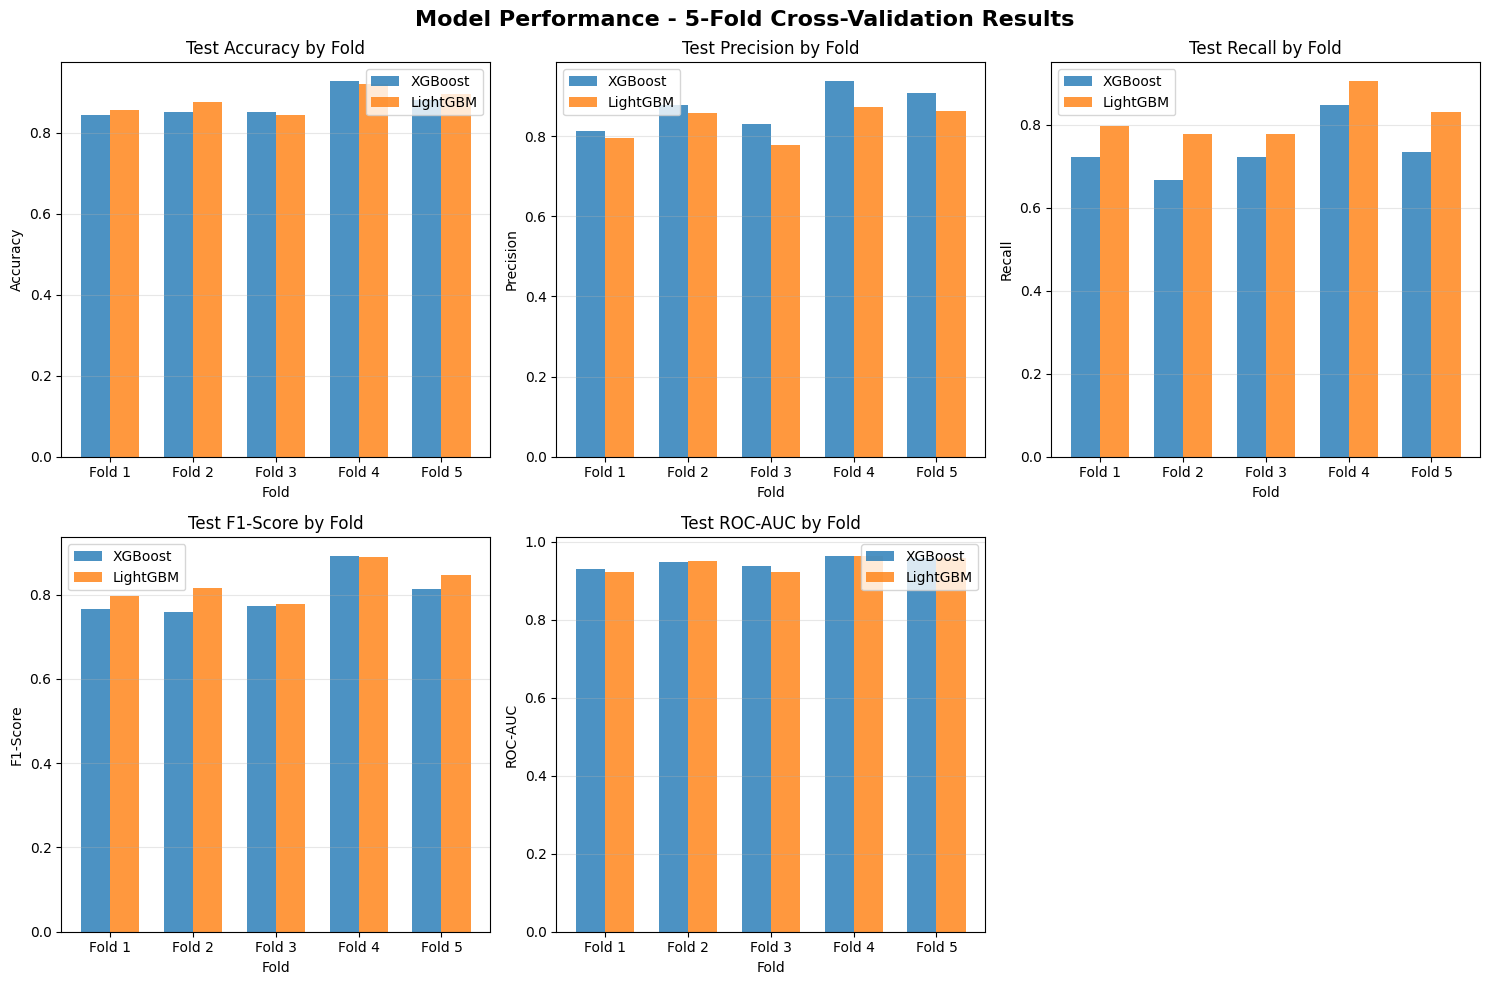


✓ Visualization saved to: c:\Users\DELL\Desktop\NSU\3rd_semester\Distributed_computing_system\Diabetes-Prediction\Diabetes-Prediction-DCS-NSU\notebooks\artifacts\model_comparison_cv.png and logged to MLflow!

DETAILED METRICS SUMMARY

📊 XGBoost Metrics Summary:
  Accuracy   (Test): 0.8712 ± 0.0314
  Precision  (Test): 0.8730 ± 0.0466
  Recall     (Test): 0.7392 ± 0.0599
  F1-Score   (Test): 0.7997 ± 0.0495
  ROC-AUC    (Test): 0.9478 ± 0.0125

📊 LightGBM Metrics Summary:
  Accuracy   (Test): 0.8790 ± 0.0275
  Precision  (Test): 0.8333 ± 0.0386
  Recall     (Test): 0.8175 ± 0.0480
  F1-Score   (Test): 0.8249 ± 0.0392
  ROC-AUC    (Test): 0.9437 ± 0.0178

🏆 BEST MODEL: XGBoost (ROC-AUC: 0.9478)
🏃 View run legendary-bug-893 at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/0e1a4eac94fe46a7a50be21290112792
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3
🏃 View run legendary-bug-893 at: https

In [25]:
import os

# Visualization of Cross-Validation Results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Model Performance - 5-Fold Cross-Validation Results', fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Plot metrics for each fold
for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 3, idx % 3]
    
    x = np.arange(len(xgb_cv_results['fold']))
    width = 0.35
    
    xgb_test_vals = xgb_cv_results[f'test_{metric}']
    lgb_test_vals = lgb_cv_results[f'test_{metric}']
    
    ax.bar(x - width/2, xgb_test_vals, width, label='XGBoost', alpha=0.8)
    ax.bar(x + width/2, lgb_test_vals, width, label='LightGBM', alpha=0.8)
    
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_title(f'Test {label} by Fold')
    ax.set_xticks(x)
    # use the actual fold numbers from results for labels
    ax.set_xticklabels([f'Fold {i}' for i in xgb_cv_results['fold']])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplot
axes[1, 2].remove()

plt.tight_layout()

# Ensure output directory exists and save locally (works on Windows and Linux)
output_dir = os.path.join(os.getcwd(), "artifacts")
os.makedirs(output_dir, exist_ok=True)
outfile = os.path.join(output_dir, "model_comparison_cv.png")

plt.savefig(outfile, dpi=300, bbox_inches='tight')
# Log the saved artifact to MLflow
mlflow.log_artifact(outfile)
plt.show()

print(f"\n✓ Visualization saved to: {outfile} and logged to MLflow!")

# Summary Statistics
print("\n" + "="*100)
print("DETAILED METRICS SUMMARY")
print("="*100)

print("\n📊 XGBoost Metrics Summary:")
print(f"  Accuracy   (Test): {xgb_avg_metrics['avg_test_accuracy']:.4f} ± {xgb_avg_metrics['std_test_accuracy']:.4f}")
print(f"  Precision  (Test): {xgb_avg_metrics['avg_test_precision']:.4f} ± {xgb_avg_metrics['std_test_precision']:.4f}")
print(f"  Recall     (Test): {xgb_avg_metrics['avg_test_recall']:.4f} ± {xgb_avg_metrics['std_test_recall']:.4f}")
print(f"  F1-Score   (Test): {xgb_avg_metrics['avg_test_f1']:.4f} ± {xgb_avg_metrics['std_test_f1']:.4f}")
print(f"  ROC-AUC    (Test): {xgb_avg_metrics['avg_test_roc_auc']:.4f} ± {xgb_avg_metrics['std_test_roc_auc']:.4f}")

print("\n📊 LightGBM Metrics Summary:")
print(f"  Accuracy   (Test): {lgb_avg_metrics['avg_test_accuracy']:.4f} ± {lgb_avg_metrics['std_test_accuracy']:.4f}")
print(f"  Precision  (Test): {lgb_avg_metrics['avg_test_precision']:.4f} ± {lgb_avg_metrics['std_test_precision']:.4f}")
print(f"  Recall     (Test): {lgb_avg_metrics['avg_test_recall']:.4f} ± {lgb_avg_metrics['std_test_recall']:.4f}")
print(f"  F1-Score   (Test): {lgb_avg_metrics['avg_test_f1']:.4f} ± {lgb_avg_metrics['std_test_f1']:.4f}")
print(f"  ROC-AUC    (Test): {lgb_avg_metrics['avg_test_roc_auc']:.4f} ± {lgb_avg_metrics['std_test_roc_auc']:.4f}")

# Determine best model
xgb_score = xgb_avg_metrics['avg_test_roc_auc']
lgb_score = lgb_avg_metrics['avg_test_roc_auc']
best_model = "XGBoost" if xgb_score > lgb_score else "LightGBM"

print("\n" + "="*100)
print(f"🏆 BEST MODEL: {best_model} (ROC-AUC: {max(xgb_score, lgb_score):.4f})")
print("="*100)

# Log summary metrics with MLflow
# If a previous MLflow run is still active, end it first to avoid "run already active" errors.
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name= "best Model Training Summary") as summary_run:
    mlflow.log_params({'best_model': best_model})
    mlflow.log_metrics({
        'xgboost_best_roc_auc': xgb_score,
        'lightgbm_best_roc_auc': lgb_score
    })
    print(f"\n✓ Summary metrics logged to MLflow with Run ID: {summary_run.info.run_id}")

print("\n✅ All experiments have been successfully tracked and logged to DagsHub!")
print(f"✅ Tracking URI: {mlflow.get_tracking_uri()}")


## DagsHub Artifact Logging Verification

In [26]:
# Verify and Display MLflow Runs with DagsHub Integration
print("\n" + "="*100)
print("DAGSHUB ARTIFACT LOGGING VERIFICATION")
print("="*100)

# Get MLflow client
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Get experiment information
experiment = client.get_experiment_by_name("Diabetes-Prediction-Experiments-colab")

print(f"\n✓ Experiment Name: {experiment.name}")
print(f"✓ Experiment ID: {experiment.experiment_id}")
print(f"✓ Artifact Location: {experiment.artifact_location}")

# List all runs in the experiment
runs = client.search_runs(experiment_ids=[experiment.experiment_id])

print(f"\n✓ Total Runs Logged: {len(runs)}")
print("\nRun Details:")
print("-" * 100)

for idx, run in enumerate(runs, 1):
    print(f"\n{idx}. Run Name: {run.data.tags.get('mlflow.runName', 'Unknown')}")
    print(f"   Run ID: {run.info.run_id}")
    print(f"   Status: {run.info.status}")
    print(f"   Artifact URI: {run.info.artifact_uri}")
    
    # List artifacts for this run
    artifacts = client.list_artifacts(run.info.run_id)
    if artifacts:
        print(f"   Artifacts ({len(artifacts)}):")
        for artifact in artifacts:
            print(f"      - {artifact.path}")
    
    # Display metrics
    if run.data.metrics:
        print(f"   Metrics: {len(run.data.metrics)} tracked")
    
    # Display params
    if run.data.params:
        print(f"   Parameters: {len(run.data.params)} logged")

print("\n" + "="*100)
print("📊 SUMMARY OF LOGGED ARTIFACTS AND METRICS")
print("="*100)

# Detailed summary
print(f"\n🔗 DagsHub Repository: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU")
print(f"🔗 MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"\n📁 All experiments and artifacts are automatically synced to DagsHub")
print(f"\n✅ XGBoost Model:")
print(f"   - 5-Fold CV Results: xgboost_cv_results.json")
print(f"   - 50 metrics tracked (5 folds × 10 metrics)")
print(f"   - Average & Standard Deviation metrics logged")

print(f"\n✅ LightGBM Model:")
print(f"   - 5-Fold CV Results: lightgbm_cv_results.json")
print(f"   - 50 metrics tracked (5 folds × 10 metrics)")
print(f"   - Average & Standard Deviation metrics logged")

print(f"\n✅ Model Comparison:")
print(f"   - Comparison metrics: models_comparison.json")
print(f"   - 10 comparison metrics (5 metrics × 2 models)")
print(f"   - Visualization: model_comparison_cv.png")

print("\n" + "="*100)
print("✨ All artifacts are now available on DagsHub!")
print("✨ You can view and manage them at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU/mlflow")
print("="*100)



DAGSHUB ARTIFACT LOGGING VERIFICATION

✓ Experiment Name: Diabetes-Prediction-Experiments-colab
✓ Experiment ID: 2
✓ Artifact Location: mlflow-artifacts:/228b117981aa425dbf4d78b6e3e9fb44

✓ Experiment Name: Diabetes-Prediction-Experiments-colab
✓ Experiment ID: 2
✓ Artifact Location: mlflow-artifacts:/228b117981aa425dbf4d78b6e3e9fb44

✓ Total Runs Logged: 0

Run Details:
----------------------------------------------------------------------------------------------------

📊 SUMMARY OF LOGGED ARTIFACTS AND METRICS

🔗 DagsHub Repository: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU
🔗 MLflow Tracking URI: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow

📁 All experiments and artifacts are automatically synced to DagsHub

✅ XGBoost Model:
   - 5-Fold CV Results: xgboost_cv_results.json
   - 50 metrics tracked (5 folds × 10 metrics)
   - Average & Standard Deviation metrics logged

✅ LightGBM Model:
   - 5-Fold CV Results: lightgbm_cv_results.json
   - 50 m

## Enhanced Visualizations and Analysis for Each Model Run


XGBOOST - DETAILED ANALYSIS AND VISUALIZATIONS



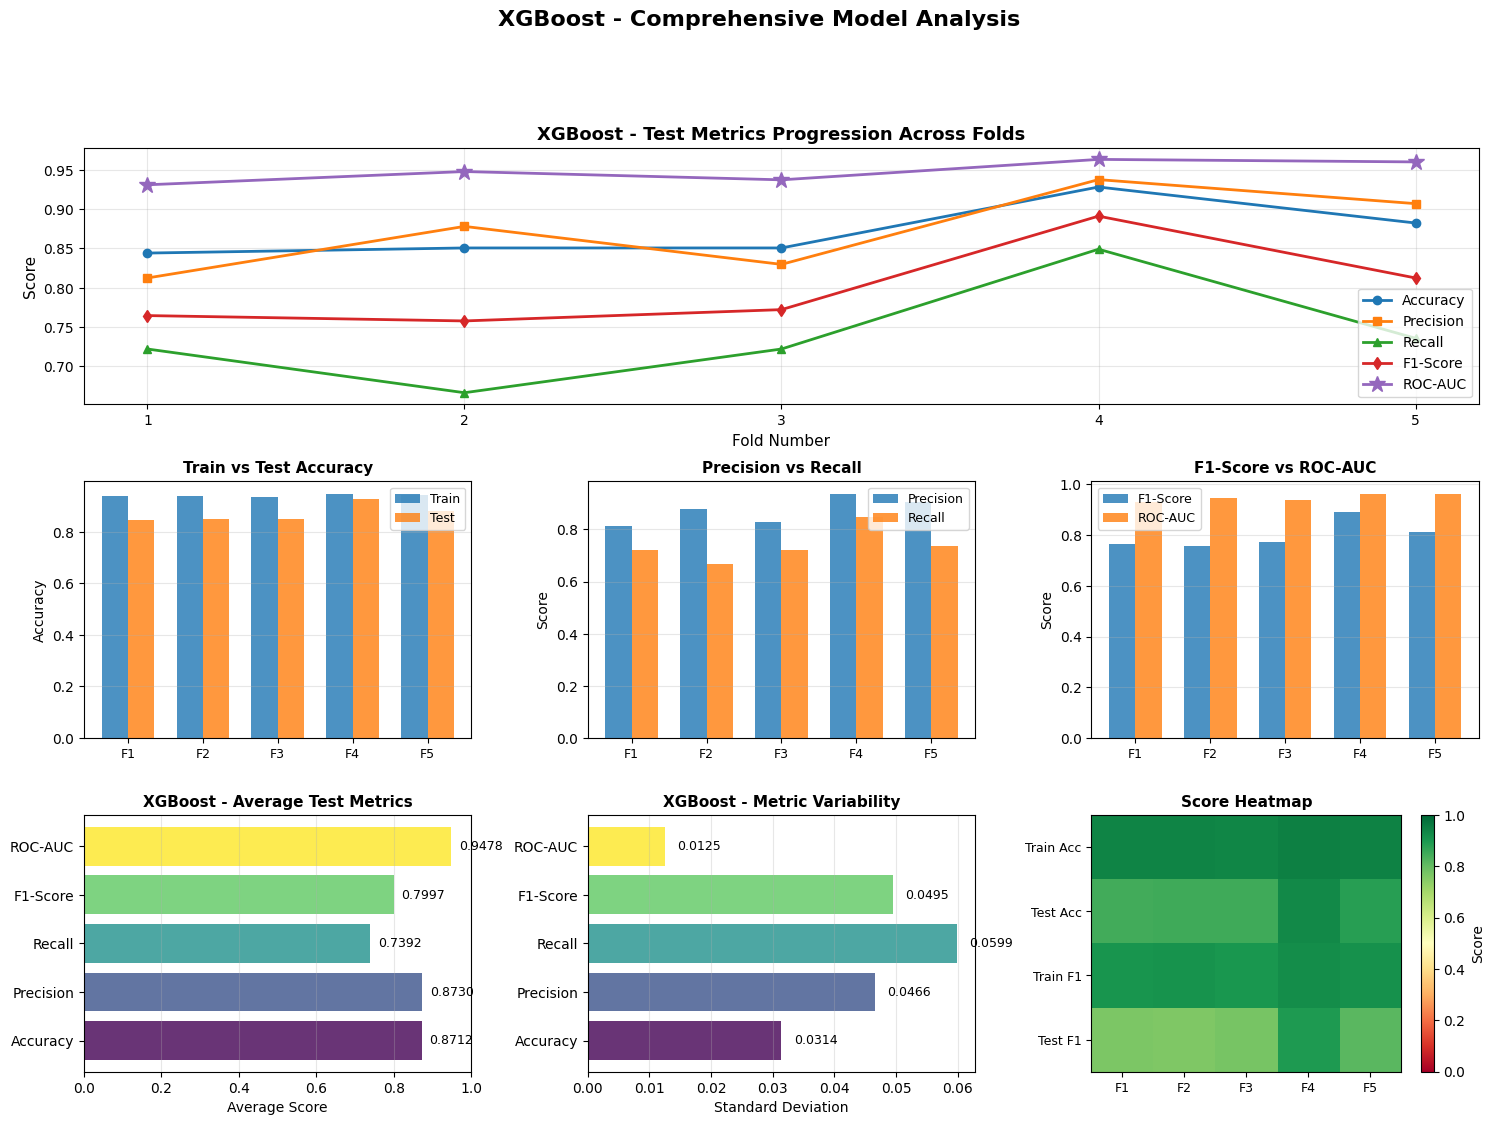

✓ XGBoost detailed analysis visualization created and logged
✓ XGBoost analysis run ID: 50e5b297f4f647ac8dd352a4528ba828
🏃 View run XGBoost-Detailed-Analysis at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/50e5b297f4f647ac8dd352a4528ba828
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3
🏃 View run XGBoost-Detailed-Analysis at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/50e5b297f4f647ac8dd352a4528ba828
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3


In [27]:
# ==================== XGBoost Detailed Analysis and Visualizations ====================
print("\n" + "="*100)
print("XGBOOST - DETAILED ANALYSIS AND VISUALIZATIONS")
print("="*100 + "\n")

with mlflow.start_run(run_name="XGBoost-Detailed-Analysis") as xgb_analysis_run:
    
    # Create comprehensive visualizations for XGBoost
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Metric progression across folds
    ax1 = fig.add_subplot(gs[0, :])
    folds = xgb_cv_results['fold']
    ax1.plot(folds, xgb_cv_results['test_accuracy'], marker='o', label='Accuracy', linewidth=2)
    ax1.plot(folds, xgb_cv_results['test_precision'], marker='s', label='Precision', linewidth=2)
    ax1.plot(folds, xgb_cv_results['test_recall'], marker='^', label='Recall', linewidth=2)
    ax1.plot(folds, xgb_cv_results['test_f1'], marker='d', label='F1-Score', linewidth=2)
    ax1.plot(folds, xgb_cv_results['test_roc_auc'], marker='*', label='ROC-AUC', linewidth=2, markersize=12)
    ax1.set_xlabel('Fold Number', fontsize=11)
    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('XGBoost - Test Metrics Progression Across Folds', fontsize=13, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(folds)
    
    # 2. Train vs Test Accuracy
    ax2 = fig.add_subplot(gs[1, 0])
    x_pos = np.arange(len(folds))
    width = 0.35
    ax2.bar(x_pos - width/2, xgb_cv_results['train_accuracy'], width, label='Train', alpha=0.8)
    ax2.bar(x_pos + width/2, xgb_cv_results['test_accuracy'], width, label='Test', alpha=0.8)
    ax2.set_ylabel('Accuracy', fontsize=10)
    ax2.set_title('Train vs Test Accuracy', fontsize=11, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Precision-Recall across folds
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.bar(x_pos - width/2, xgb_cv_results['test_precision'], width, label='Precision', alpha=0.8)
    ax3.bar(x_pos + width/2, xgb_cv_results['test_recall'], width, label='Recall', alpha=0.8)
    ax3.set_ylabel('Score', fontsize=10)
    ax3.set_title('Precision vs Recall', fontsize=11, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. F1-Score ROC-AUC
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.bar(x_pos - width/2, xgb_cv_results['test_f1'], width, label='F1-Score', alpha=0.8)
    ax4.bar(x_pos + width/2, xgb_cv_results['test_roc_auc'], width, label='ROC-AUC', alpha=0.8)
    ax4.set_ylabel('Score', fontsize=10)
    ax4.set_title('F1-Score vs ROC-AUC', fontsize=11, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax4.legend(fontsize=9)
    ax4.grid(axis='y', alpha=0.3)
    
    # 5. Average metrics comparison
    ax5 = fig.add_subplot(gs[2, 0])
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    avg_scores = [
        xgb_avg_metrics['avg_test_accuracy'],
        xgb_avg_metrics['avg_test_precision'],
        xgb_avg_metrics['avg_test_recall'],
        xgb_avg_metrics['avg_test_f1'],
        xgb_avg_metrics['avg_test_roc_auc']
    ]
    colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_names)))
    bars = ax5.barh(metrics_names, avg_scores, color=colors, alpha=0.8)
    ax5.set_xlabel('Average Score', fontsize=10)
    ax5.set_title('XGBoost - Average Test Metrics', fontsize=11, fontweight='bold')
    ax5.set_xlim(0, 1)
    for i, bar in enumerate(bars):
        width_bar = bar.get_width()
        ax5.text(width_bar + 0.02, bar.get_y() + bar.get_height()/2, f'{width_bar:.4f}', 
                ha='left', va='center', fontsize=9)
    ax5.grid(axis='x', alpha=0.3)
    
    # 6. Standard deviations
    ax6 = fig.add_subplot(gs[2, 1])
    std_scores = [
        xgb_avg_metrics['std_test_accuracy'],
        xgb_avg_metrics['std_test_precision'],
        xgb_avg_metrics['std_test_recall'],
        xgb_avg_metrics['std_test_f1'],
        xgb_avg_metrics['std_test_roc_auc']
    ]
    bars = ax6.barh(metrics_names, std_scores, color=colors, alpha=0.8)
    ax6.set_xlabel('Standard Deviation', fontsize=10)
    ax6.set_title('XGBoost - Metric Variability', fontsize=11, fontweight='bold')
    for i, bar in enumerate(bars):
        width_bar = bar.get_width()
        ax6.text(width_bar + 0.002, bar.get_y() + bar.get_height()/2, f'{width_bar:.4f}', 
                ha='left', va='center', fontsize=9)
    ax6.grid(axis='x', alpha=0.3)
    
    # 7. Train vs Test scores heatmap-like view
    ax7 = fig.add_subplot(gs[2, 2])
    train_test_data = [
        xgb_cv_results['train_accuracy'],
        xgb_cv_results['test_accuracy'],
        xgb_cv_results['train_f1'],
        xgb_cv_results['test_f1']
    ]
    im = ax7.imshow(train_test_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax7.set_yticks(range(4))
    ax7.set_yticklabels(['Train Acc', 'Test Acc', 'Train F1', 'Test F1'], fontsize=9)
    ax7.set_xticks(range(len(folds)))
    ax7.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax7.set_title('Score Heatmap', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax7, label='Score')
    
    plt.suptitle('XGBoost - Comprehensive Model Analysis', fontsize=16, fontweight='bold', y=0.995)
    
    # Save XGBoost analysis visualization
    xgb_viz_path = os.path.join(output_dir, "xgboost_detailed_analysis.png")
    plt.savefig(xgb_viz_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(xgb_viz_path)
    plt.show()
    
    # Log detailed statistics
    mlflow.log_dict({
        'fold_metrics': xgb_cv_results,
        'average_metrics': xgb_avg_metrics,
        'hyperparameters': xgb_params,
        'model_type': 'XGBoost Classifier'
    }, "xgboost_detailed_report.json")
    
    # Log hyperparameters details
    mlflow.log_params({
        'model_type': 'XGBoost',
        'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold'
    })
    
    print("✓ XGBoost detailed analysis visualization created and logged")
    print(f"✓ XGBoost analysis run ID: {xgb_analysis_run.info.run_id}")



LIGHTGBM - DETAILED ANALYSIS AND VISUALIZATIONS



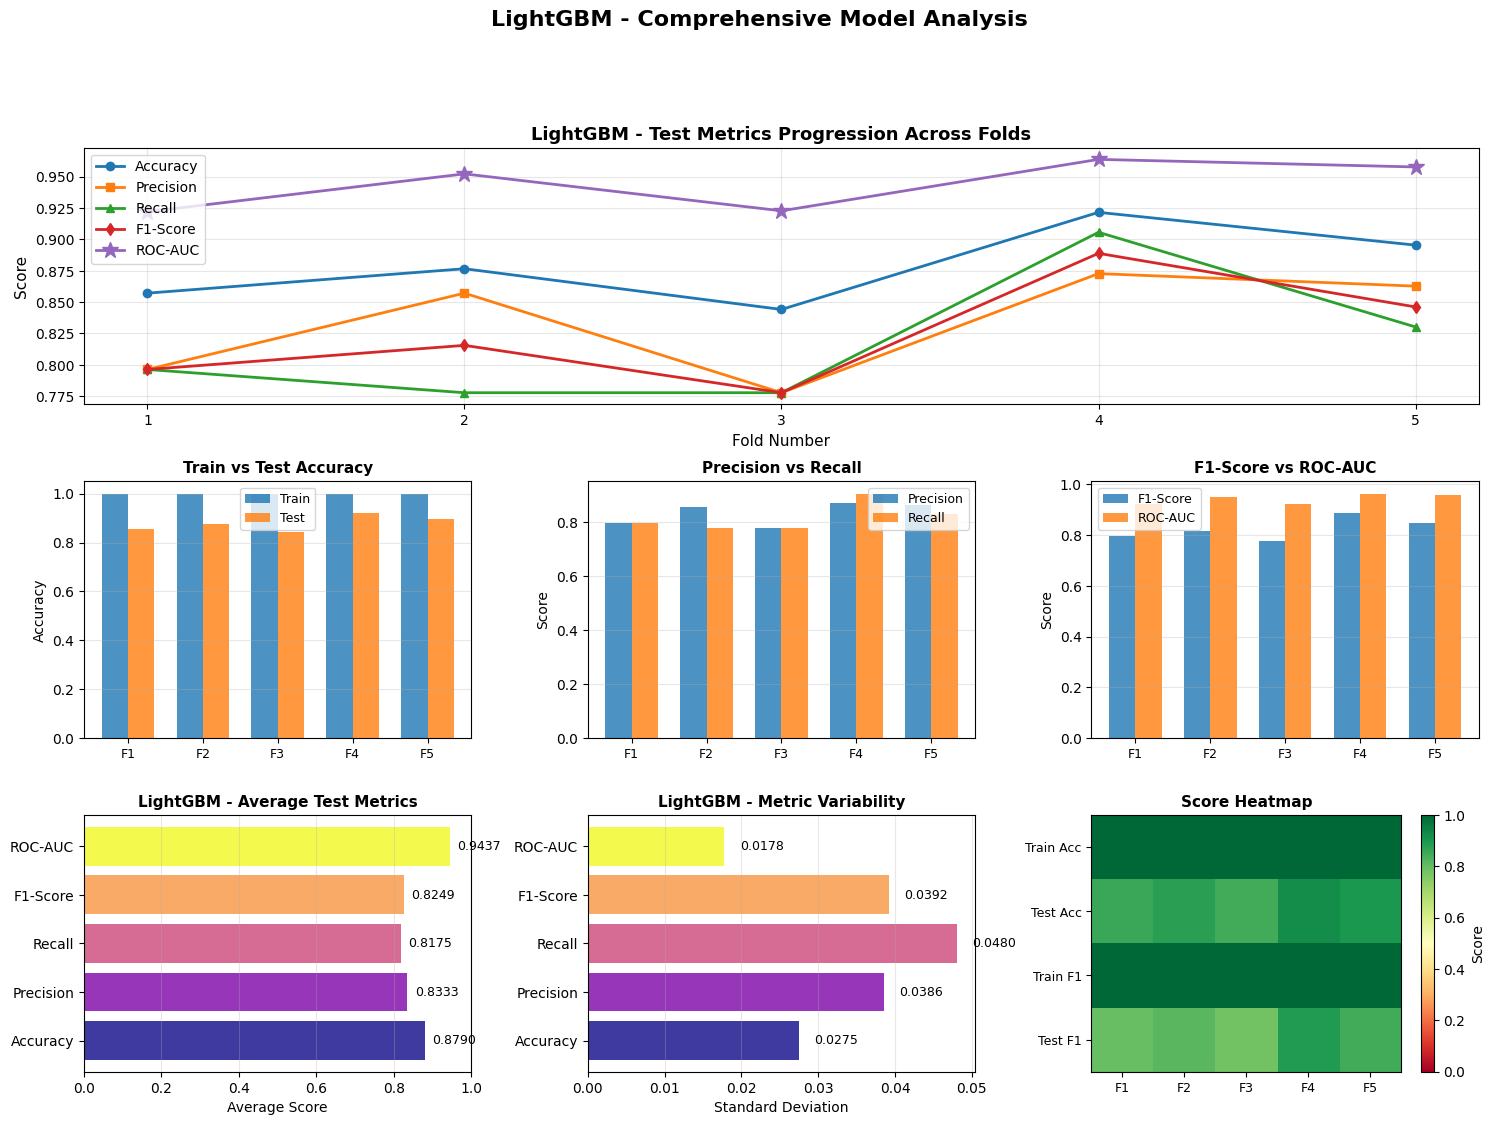

✓ LightGBM detailed analysis visualization created and logged
✓ LightGBM analysis run ID: da007da184ff40fb914d468e80c4d76a
🏃 View run LightGBM-Detailed-Analysis at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/da007da184ff40fb914d468e80c4d76a
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3
🏃 View run LightGBM-Detailed-Analysis at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/da007da184ff40fb914d468e80c4d76a
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3


In [28]:
# ==================== LightGBM Detailed Analysis and Visualizations ====================
print("\n" + "="*100)
print("LIGHTGBM - DETAILED ANALYSIS AND VISUALIZATIONS")
print("="*100 + "\n")

with mlflow.start_run(run_name="LightGBM-Detailed-Analysis") as lgb_analysis_run:
    
    # Create comprehensive visualizations for LightGBM
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Metric progression across folds
    ax1 = fig.add_subplot(gs[0, :])
    folds = lgb_cv_results['fold']
    ax1.plot(folds, lgb_cv_results['test_accuracy'], marker='o', label='Accuracy', linewidth=2)
    ax1.plot(folds, lgb_cv_results['test_precision'], marker='s', label='Precision', linewidth=2)
    ax1.plot(folds, lgb_cv_results['test_recall'], marker='^', label='Recall', linewidth=2)
    ax1.plot(folds, lgb_cv_results['test_f1'], marker='d', label='F1-Score', linewidth=2)
    ax1.plot(folds, lgb_cv_results['test_roc_auc'], marker='*', label='ROC-AUC', linewidth=2, markersize=12)
    ax1.set_xlabel('Fold Number', fontsize=11)
    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('LightGBM - Test Metrics Progression Across Folds', fontsize=13, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(folds)
    
    # 2. Train vs Test Accuracy
    ax2 = fig.add_subplot(gs[1, 0])
    x_pos = np.arange(len(folds))
    width = 0.35
    ax2.bar(x_pos - width/2, lgb_cv_results['train_accuracy'], width, label='Train', alpha=0.8)
    ax2.bar(x_pos + width/2, lgb_cv_results['test_accuracy'], width, label='Test', alpha=0.8)
    ax2.set_ylabel('Accuracy', fontsize=10)
    ax2.set_title('Train vs Test Accuracy', fontsize=11, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Precision-Recall across folds
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.bar(x_pos - width/2, lgb_cv_results['test_precision'], width, label='Precision', alpha=0.8)
    ax3.bar(x_pos + width/2, lgb_cv_results['test_recall'], width, label='Recall', alpha=0.8)
    ax3.set_ylabel('Score', fontsize=10)
    ax3.set_title('Precision vs Recall', fontsize=11, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. F1-Score ROC-AUC
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.bar(x_pos - width/2, lgb_cv_results['test_f1'], width, label='F1-Score', alpha=0.8)
    ax4.bar(x_pos + width/2, lgb_cv_results['test_roc_auc'], width, label='ROC-AUC', alpha=0.8)
    ax4.set_ylabel('Score', fontsize=10)
    ax4.set_title('F1-Score vs ROC-AUC', fontsize=11, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax4.legend(fontsize=9)
    ax4.grid(axis='y', alpha=0.3)
    
    # 5. Average metrics comparison
    ax5 = fig.add_subplot(gs[2, 0])
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    avg_scores = [
        lgb_avg_metrics['avg_test_accuracy'],
        lgb_avg_metrics['avg_test_precision'],
        lgb_avg_metrics['avg_test_recall'],
        lgb_avg_metrics['avg_test_f1'],
        lgb_avg_metrics['avg_test_roc_auc']
    ]
    colors = plt.cm.plasma(np.linspace(0, 1, len(metrics_names)))
    bars = ax5.barh(metrics_names, avg_scores, color=colors, alpha=0.8)
    ax5.set_xlabel('Average Score', fontsize=10)
    ax5.set_title('LightGBM - Average Test Metrics', fontsize=11, fontweight='bold')
    ax5.set_xlim(0, 1)
    for i, bar in enumerate(bars):
        width_bar = bar.get_width()
        ax5.text(width_bar + 0.02, bar.get_y() + bar.get_height()/2, f'{width_bar:.4f}', 
                ha='left', va='center', fontsize=9)
    ax5.grid(axis='x', alpha=0.3)
    
    # 6. Standard deviations
    ax6 = fig.add_subplot(gs[2, 1])
    std_scores = [
        lgb_avg_metrics['std_test_accuracy'],
        lgb_avg_metrics['std_test_precision'],
        lgb_avg_metrics['std_test_recall'],
        lgb_avg_metrics['std_test_f1'],
        lgb_avg_metrics['std_test_roc_auc']
    ]
    bars = ax6.barh(metrics_names, std_scores, color=colors, alpha=0.8)
    ax6.set_xlabel('Standard Deviation', fontsize=10)
    ax6.set_title('LightGBM - Metric Variability', fontsize=11, fontweight='bold')
    for i, bar in enumerate(bars):
        width_bar = bar.get_width()
        ax6.text(width_bar + 0.002, bar.get_y() + bar.get_height()/2, f'{width_bar:.4f}', 
                ha='left', va='center', fontsize=9)
    ax6.grid(axis='x', alpha=0.3)
    
    # 7. Train vs Test scores heatmap-like view
    ax7 = fig.add_subplot(gs[2, 2])
    train_test_data = [
        lgb_cv_results['train_accuracy'],
        lgb_cv_results['test_accuracy'],
        lgb_cv_results['train_f1'],
        lgb_cv_results['test_f1']
    ]
    im = ax7.imshow(train_test_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax7.set_yticks(range(4))
    ax7.set_yticklabels(['Train Acc', 'Test Acc', 'Train F1', 'Test F1'], fontsize=9)
    ax7.set_xticks(range(len(folds)))
    ax7.set_xticklabels([f'F{i}' for i in folds], fontsize=9)
    ax7.set_title('Score Heatmap', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax7, label='Score')
    
    plt.suptitle('LightGBM - Comprehensive Model Analysis', fontsize=16, fontweight='bold', y=0.995)
    
    # Save LightGBM analysis visualization
    lgb_viz_path = os.path.join(output_dir, "lightgbm_detailed_analysis.png")
    plt.savefig(lgb_viz_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(lgb_viz_path)
    plt.show()
    
    # Log detailed statistics
    mlflow.log_dict({
        'fold_metrics': lgb_cv_results,
        'average_metrics': lgb_avg_metrics,
        'hyperparameters': lgb_params,
        'model_type': 'LightGBM Classifier'
    }, "lightgbm_detailed_report.json")
    
    # Log hyperparameters details
    mlflow.log_params({
        'model_type': 'LightGBM',
        'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold'
    })
    
    print("✓ LightGBM detailed analysis visualization created and logged")
    print(f"✓ LightGBM analysis run ID: {lgb_analysis_run.info.run_id}")



COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS



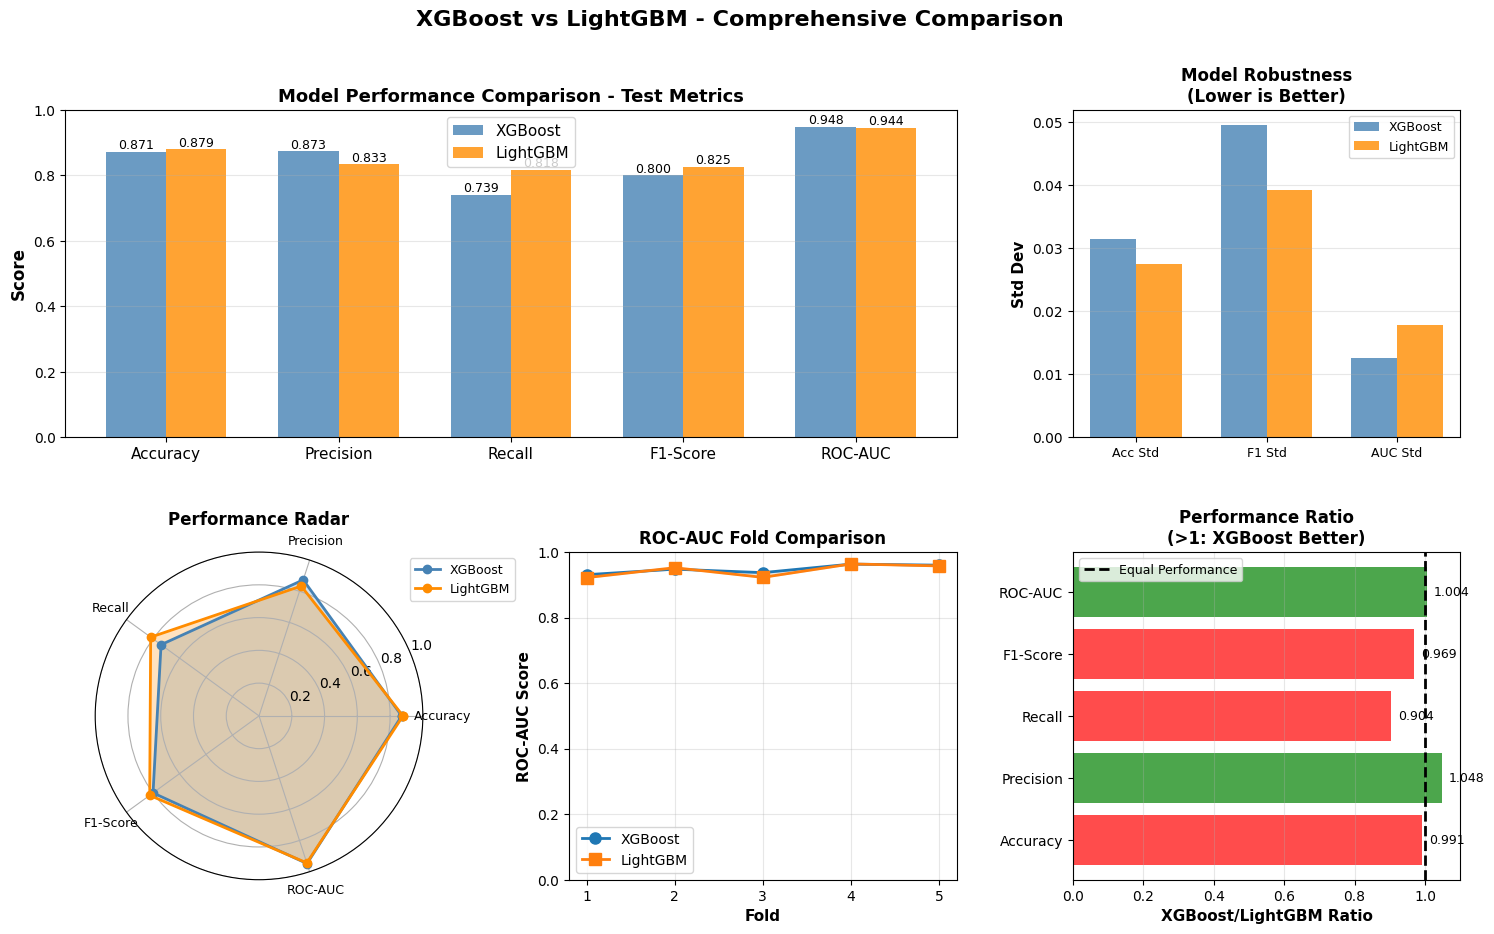

✓ Model comparison visualizations created and logged
✓ Comparison visualization run ID: 864ac32c7be44db69bed8fb2b2f181f1
🏃 View run Model-Comparison-Visualizations at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/864ac32c7be44db69bed8fb2b2f181f1
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3
🏃 View run Model-Comparison-Visualizations at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3/runs/864ac32c7be44db69bed8fb2b2f181f1
🧪 View experiment at: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow/#/experiments/3


In [29]:
# ==================== Model Comparison Visualizations ====================
print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS")
print("="*100 + "\n")

with mlflow.start_run(run_name="Model-Comparison-Visualizations") as comparison_viz_run:
    
    # Create comparison visualizations
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)
    
    # 1. Overall metrics comparison
    ax1 = fig.add_subplot(gs[0, :2])
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    xgb_scores = [
        xgb_avg_metrics['avg_test_accuracy'],
        xgb_avg_metrics['avg_test_precision'],
        xgb_avg_metrics['avg_test_recall'],
        xgb_avg_metrics['avg_test_f1'],
        xgb_avg_metrics['avg_test_roc_auc']
    ]
    lgb_scores = [
        lgb_avg_metrics['avg_test_accuracy'],
        lgb_avg_metrics['avg_test_precision'],
        lgb_avg_metrics['avg_test_recall'],
        lgb_avg_metrics['avg_test_f1'],
        lgb_avg_metrics['avg_test_roc_auc']
    ]
    
    x_pos = np.arange(len(metrics_names))
    width = 0.35
    bars1 = ax1.bar(x_pos - width/2, xgb_scores, width, label='XGBoost', alpha=0.8, color='steelblue')
    bars2 = ax1.bar(x_pos + width/2, lgb_scores, width, label='LightGBM', alpha=0.8, color='darkorange')
    
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('Model Performance Comparison - Test Metrics', fontsize=13, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(metrics_names, fontsize=11)
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim(0, 1)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 2. Model robustness (std dev comparison)
    ax2 = fig.add_subplot(gs[0, 2])
    xgb_stds = [
        xgb_avg_metrics['std_test_accuracy'],
        xgb_avg_metrics['std_test_f1'],
        xgb_avg_metrics['std_test_roc_auc']
    ]
    lgb_stds = [
        lgb_avg_metrics['std_test_accuracy'],
        lgb_avg_metrics['std_test_f1'],
        lgb_avg_metrics['std_test_roc_auc']
    ]
    metric_labels = ['Acc Std', 'F1 Std', 'AUC Std']
    x_pos_std = np.arange(len(metric_labels))
    ax2.bar(x_pos_std - width/2, xgb_stds, width, label='XGBoost', alpha=0.8, color='steelblue')
    ax2.bar(x_pos_std + width/2, lgb_stds, width, label='LightGBM', alpha=0.8, color='darkorange')
    ax2.set_ylabel('Std Dev', fontsize=11, fontweight='bold')
    ax2.set_title('Model Robustness\n(Lower is Better)', fontsize=12, fontweight='bold')
    ax2.set_xticks(x_pos_std)
    ax2.set_xticklabels(metric_labels, fontsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Radar-like comparison (top metrics)
    ax3 = fig.add_subplot(gs[1, 0], projection='polar')
    angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
    angles += angles[:1]  # complete the circle
    
    xgb_scores_plot = xgb_scores + xgb_scores[:1]
    lgb_scores_plot = lgb_scores + lgb_scores[:1]
    
    ax3.plot(angles, xgb_scores_plot, 'o-', linewidth=2, label='XGBoost', color='steelblue')
    ax3.fill(angles, xgb_scores_plot, alpha=0.25, color='steelblue')
    ax3.plot(angles, lgb_scores_plot, 'o-', linewidth=2, label='LightGBM', color='darkorange')
    ax3.fill(angles, lgb_scores_plot, alpha=0.25, color='darkorange')
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(metrics_names, fontsize=9)
    ax3.set_ylim(0, 1)
    ax3.set_title('Performance Radar', fontsize=12, fontweight='bold', pad=20)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
    ax3.grid(True)
    
    # 4. Fold-by-fold ROC-AUC comparison
    ax4 = fig.add_subplot(gs[1, 1])
    folds_x = np.arange(len(xgb_cv_results['fold']))
    ax4.plot(folds_x, xgb_cv_results['test_roc_auc'], marker='o', label='XGBoost', linewidth=2, markersize=8)
    ax4.plot(folds_x, lgb_cv_results['test_roc_auc'], marker='s', label='LightGBM', linewidth=2, markersize=8)
    ax4.fill_between(folds_x, xgb_cv_results['test_roc_auc'], lgb_cv_results['test_roc_auc'], 
                      alpha=0.2, color='gray')
    ax4.set_xlabel('Fold', fontsize=11, fontweight='bold')
    ax4.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
    ax4.set_title('ROC-AUC Fold Comparison', fontsize=12, fontweight='bold')
    ax4.set_xticks(folds_x)
    ax4.set_xticklabels(xgb_cv_results['fold'], fontsize=10)
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 1)
    
    # 5. Performance ratio
    ax5 = fig.add_subplot(gs[1, 2])
    ratios = [xgb_s / lgb_s if lgb_s > 0 else 1 for xgb_s, lgb_s in zip(xgb_scores, lgb_scores)]
    colors_ratio = ['green' if r > 1 else 'red' for r in ratios]
    bars = ax5.barh(metrics_names, ratios, color=colors_ratio, alpha=0.7)
    ax5.axvline(x=1, color='black', linestyle='--', linewidth=2, label='Equal Performance')
    ax5.set_xlabel('XGBoost/LightGBM Ratio', fontsize=11, fontweight='bold')
    ax5.set_title('Performance Ratio\n(>1: XGBoost Better)', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(axis='x', alpha=0.3)
    
    for i, (bar, ratio) in enumerate(zip(bars, ratios)):
        ax5.text(ratio + 0.02, bar.get_y() + bar.get_height()/2, f'{ratio:.3f}',
                ha='left', va='center', fontsize=9)
    
    plt.suptitle('XGBoost vs LightGBM - Comprehensive Comparison', fontsize=16, fontweight='bold', y=0.98)
    
    # Save comparison visualization
    comparison_viz_path = os.path.join(output_dir, "model_comparison_detailed.png")
    plt.savefig(comparison_viz_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(comparison_viz_path)
    plt.show()
    
    # Log comparison summary
    comparison_summary = {
        'metrics': metrics_names,
        'xgboost_scores': [float(x) for x in xgb_scores],
        'lightgbm_scores': [float(x) for x in lgb_scores],
        'xgboost_stds': [float(x) for x in xgb_stds],
        'lightgbm_stds': [float(x) for x in lgb_stds],
        'performance_ratios': [float(x) for x in ratios]
    }
    mlflow.log_dict(comparison_summary, "model_comparison_summary.json")
    
    # Log comparison metrics
    for i, metric in enumerate(metrics_names):
        mlflow.log_metric(f"comparison_{metric.lower()}_xgb", xgb_scores[i])
        mlflow.log_metric(f"comparison_{metric.lower()}_lgb", lgb_scores[i])
    
    print("✓ Model comparison visualizations created and logged")
    print(f"✓ Comparison visualization run ID: {comparison_viz_run.info.run_id}")


## Train Best Model on Full Data and Save


TRAINING BEST MODEL ON FULL DATA AND SAVING

🏆 Best Model Selected: XGBoost
   XGBoost ROC-AUC: 0.9478
   LightGBM ROC-AUC: 0.9437
   Difference: 0.0041

Training XGBoost on full dataset...
Training XGBoost on full dataset...

Metrics on Full Data (768 samples):
  Accuracy:  0.9375
  Precision: 0.9741
  Recall:    0.8433
  F1-Score:  0.9040
  ROC-AUC:   0.9885

Confusion Matrix:
  TN: 494, FP: 6
  FN: 42, TP: 226

Metrics on Full Data (768 samples):
  Accuracy:  0.9375
  Precision: 0.9741
  Recall:    0.8433
  F1-Score:  0.9040
  ROC-AUC:   0.9885

Confusion Matrix:
  TN: 494, FP: 6
  FN: 42, TP: 226


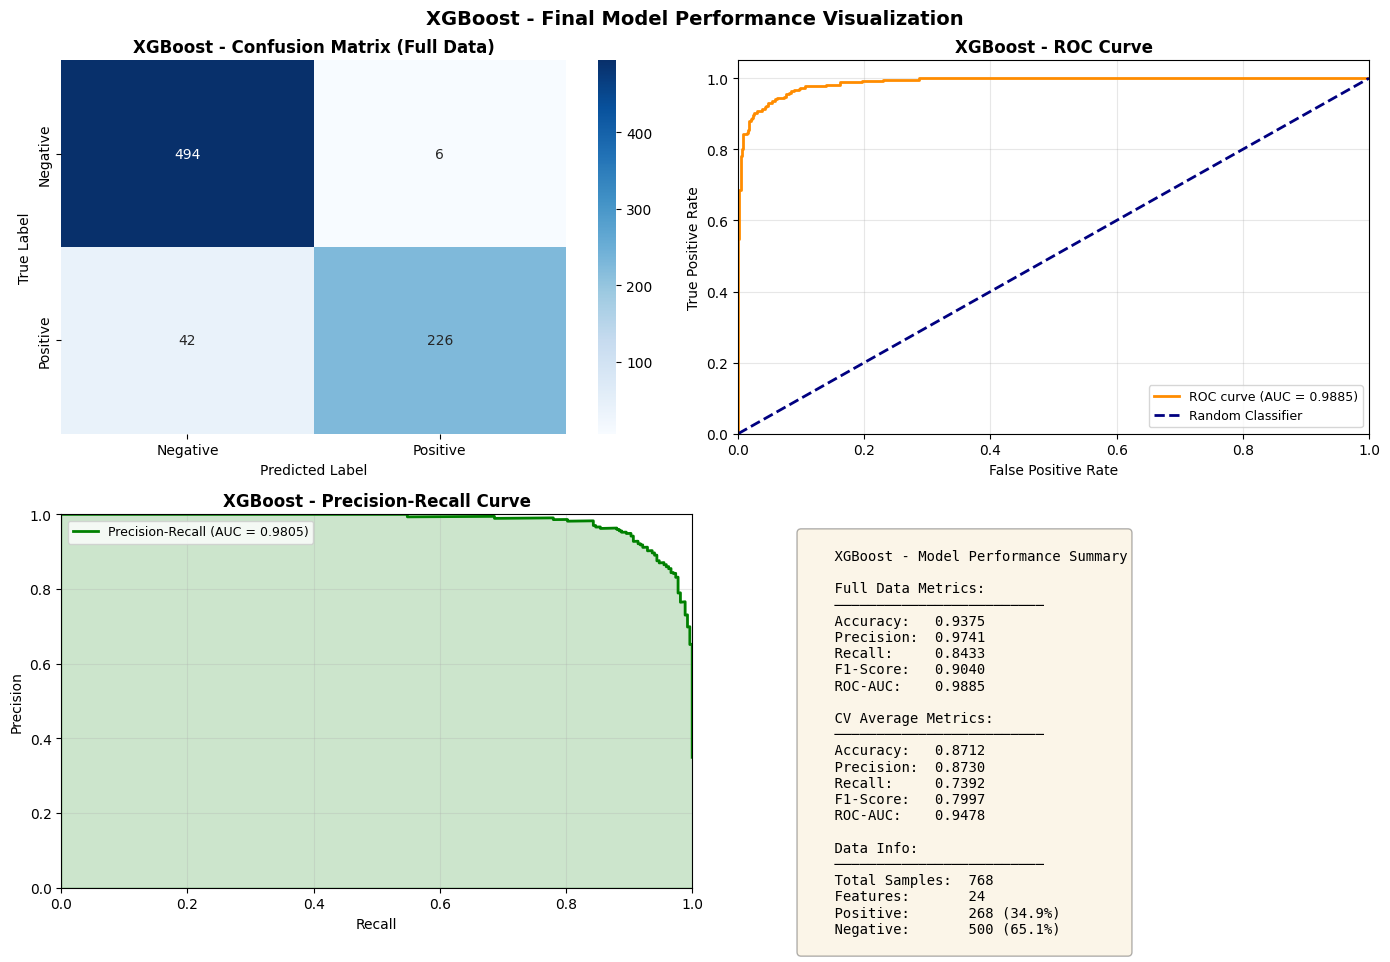


✓ Best model visualizations created and logged

----------------------------------------------------------------------------------------------------
SAVING MODEL FILES
----------------------------------------------------------------------------------------------------
✓ Model saved (joblib): c:\Users\DELL\Desktop\NSU\3rd_semester\Distributed_computing_system\Diabetes-Prediction\Diabetes-Prediction-DCS-NSU\notebooks\models\xgboost_best_model_20251027_161516.joblib
✓ Model saved (pickle): c:\Users\DELL\Desktop\NSU\3rd_semester\Distributed_computing_system\Diabetes-Prediction\Diabetes-Prediction-DCS-NSU\notebooks\models\xgboost_best_model_20251027_161516.pkl
✓ Models logged to MLflow artifacts
✓ Models logged to MLflow artifacts
✓ Model metadata saved: c:\Users\DELL\Desktop\NSU\3rd_semester\Distributed_computing_system\Diabetes-Prediction\Diabetes-Prediction-DCS-NSU\notebooks\models\xgboost_best_model_20251027_161516_metadata.json

✅ BEST MODEL TRAINING AND SAVING COMPLETED

📊 Final Mode

In [30]:
import pickle
import joblib
from datetime import datetime

print("\n" + "="*100)
print("TRAINING BEST MODEL ON FULL DATA AND SAVING")
print("="*100 + "\n")

# Determine best model and train it on full dataset
xgb_score = xgb_avg_metrics['avg_test_roc_auc']
lgb_score = lgb_avg_metrics['avg_test_roc_auc']
best_model_name = "XGBoost" if xgb_score > lgb_score else "LightGBM"

print(f"🏆 Best Model Selected: {best_model_name}")
print(f"   XGBoost ROC-AUC: {xgb_score:.4f}")
print(f"   LightGBM ROC-AUC: {lgb_score:.4f}")
print(f"   Difference: {abs(xgb_score - lgb_score):.4f}\n")

# Start MLflow run for best model training
with mlflow.start_run(run_name=f"Best-Model-{best_model_name}-Full-Training") as best_model_run:
    
    # Train best model on full data
    if best_model_name == "XGBoost":
        print("Training XGBoost on full dataset...")
        best_model = xgb.XGBClassifier(**xgb_params)
        best_model.fit(X, y)
        best_params = xgb_params
        best_cv_results = xgb_cv_results
        best_avg_metrics = xgb_avg_metrics
    else:
        print("Training LightGBM on full dataset...")
        best_model = lgb.LGBMClassifier(**lgb_params)
        best_model.fit(X, y)
        best_params = lgb_params
        best_cv_results = lgb_cv_results
        best_avg_metrics = lgb_avg_metrics
    
    # Get predictions on full data for analysis
    y_pred = best_model.predict(X)
    y_pred_proba = best_model.predict_proba(X)[:, 1]
    
    # Calculate full data metrics
    full_accuracy = accuracy_score(y, y_pred)
    full_precision = precision_score(y, y_pred, zero_division=0)
    full_recall = recall_score(y, y_pred, zero_division=0)
    full_f1 = f1_score(y, y_pred, zero_division=0)
    full_roc_auc = roc_auc_score(y, y_pred_proba)
    
    # Get confusion matrix
    cm = confusion_matrix(y, y_pred)
    
    # Get classification report
    class_report = classification_report(y, y_pred, output_dict=True)
    
    # Log parameters
    mlflow.log_params({
        'best_model': best_model_name,
        'trained_on': 'full_data',
        'data_samples': len(X),
        'features': X.shape[1]
    })
    
    # Log hyperparameters
    for key, val in best_params.items():
        if not isinstance(val, dict):
            mlflow.log_param(f"param_{key}", val)
    
    # Log full data metrics
    mlflow.log_metric("full_data_accuracy", full_accuracy)
    mlflow.log_metric("full_data_precision", full_precision)
    mlflow.log_metric("full_data_recall", full_recall)
    mlflow.log_metric("full_data_f1", full_f1)
    mlflow.log_metric("full_data_roc_auc", full_roc_auc)
    
    # Log cross-validation metrics for reference
    mlflow.log_metric("cv_avg_accuracy", best_avg_metrics['avg_test_accuracy'])
    mlflow.log_metric("cv_avg_precision", best_avg_metrics['avg_test_precision'])
    mlflow.log_metric("cv_avg_recall", best_avg_metrics['avg_test_recall'])
    mlflow.log_metric("cv_avg_f1", best_avg_metrics['avg_test_f1'])
    mlflow.log_metric("cv_avg_roc_auc", best_avg_metrics['avg_test_roc_auc'])
    
    print(f"\nMetrics on Full Data ({len(X)} samples):")
    print(f"  Accuracy:  {full_accuracy:.4f}")
    print(f"  Precision: {full_precision:.4f}")
    print(f"  Recall:    {full_recall:.4f}")
    print(f"  F1-Score:  {full_f1:.4f}")
    print(f"  ROC-AUC:   {full_roc_auc:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(f"  TN: {cm[0, 0]}, FP: {cm[0, 1]}")
    print(f"  FN: {cm[1, 0]}, TP: {cm[1, 1]}")
    
    # Create visualizations for best model
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Confusion Matrix Heatmap
    ax1 = axes[0, 0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=True, 
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    ax1.set_title(f'{best_model_name} - Confusion Matrix (Full Data)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=10)
    ax1.set_xlabel('Predicted Label', fontsize=10)
    
    # 2. ROC Curve
    ax2 = axes[0, 1]
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate', fontsize=10)
    ax2.set_ylabel('True Positive Rate', fontsize=10)
    ax2.set_title(f'{best_model_name} - ROC Curve', fontsize=12, fontweight='bold')
    ax2.legend(loc="lower right", fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Precision-Recall Curve
    ax3 = axes[1, 0]
    from sklearn.metrics import precision_recall_curve, auc as pr_auc
    precision, recall, _ = precision_recall_curve(y, y_pred_proba)
    pr_auc_score = pr_auc(recall, precision)
    ax3.plot(recall, precision, color='green', lw=2, label=f'Precision-Recall (AUC = {pr_auc_score:.4f})')
    ax3.fill_between(recall, precision, alpha=0.2, color='green')
    ax3.set_xlabel('Recall', fontsize=10)
    ax3.set_ylabel('Precision', fontsize=10)
    ax3.set_title(f'{best_model_name} - Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax3.legend(loc="best", fontsize=9)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([0, 1])
    ax3.set_ylim([0, 1])
    
    # 4. Metrics Summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    metrics_text = f"""
    {best_model_name} - Model Performance Summary
    
    Full Data Metrics:
    ─────────────────────────
    Accuracy:   {full_accuracy:.4f}
    Precision:  {full_precision:.4f}
    Recall:     {full_recall:.4f}
    F1-Score:   {full_f1:.4f}
    ROC-AUC:    {full_roc_auc:.4f}
    
    CV Average Metrics:
    ─────────────────────────
    Accuracy:   {best_avg_metrics['avg_test_accuracy']:.4f}
    Precision:  {best_avg_metrics['avg_test_precision']:.4f}
    Recall:     {best_avg_metrics['avg_test_recall']:.4f}
    F1-Score:   {best_avg_metrics['avg_test_f1']:.4f}
    ROC-AUC:    {best_avg_metrics['avg_test_roc_auc']:.4f}
    
    Data Info:
    ─────────────────────────
    Total Samples:  {len(X)}
    Features:       {X.shape[1]}
    Positive:       {sum(y)} ({100*sum(y)/len(y):.1f}%)
    Negative:       {len(y)-sum(y)} ({100*(len(y)-sum(y))/len(y):.1f}%)
    """
    
    ax4.text(0.1, 0.95, metrics_text, transform=ax4.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle(f'{best_model_name} - Final Model Performance Visualization', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save best model visualization
    best_model_viz_path = os.path.join(output_dir, f"{best_model_name.lower()}_best_model_analysis.png")
    plt.savefig(best_model_viz_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(best_model_viz_path)
    plt.show()
    
    print("\n✓ Best model visualizations created and logged")
    
    # Save model files
    print("\n" + "-"*100)
    print("SAVING MODEL FILES")
    print("-"*100)
    
    # Create models directory
    models_dir = os.path.join(os.getcwd(), "models")
    os.makedirs(models_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save using joblib (recommended for sklearn-based models)
    model_joblib_path = os.path.join(models_dir, f"{best_model_name.lower()}_best_model_{timestamp}.joblib")
    joblib.dump(best_model, model_joblib_path)
    print(f"✓ Model saved (joblib): {model_joblib_path}")
    
    # Save using pickle
    model_pickle_path = os.path.join(models_dir, f"{best_model_name.lower()}_best_model_{timestamp}.pkl")
    with open(model_pickle_path, 'wb') as f:
        pickle.dump(best_model, f)
    print(f"✓ Model saved (pickle): {model_pickle_path}")
    
    # Log models as MLflow artifacts
    mlflow.log_artifact(model_joblib_path, "models")
    mlflow.log_artifact(model_pickle_path, "models")
    print("✓ Models logged to MLflow artifacts")
    
    # Save model metadata
    model_metadata = {
        'model_type': best_model_name,
        'training_date': datetime.now().isoformat(),
        'data_samples': len(X),
        'features': int(X.shape[1]),
        'hyperparameters': best_params,
        'full_data_metrics': {
            'accuracy': float(full_accuracy),
            'precision': float(full_precision),
            'recall': float(full_recall),
            'f1_score': float(full_f1),
            'roc_auc': float(full_roc_auc)
        },
        'cv_metrics': {
            'cv_avg_accuracy': float(best_avg_metrics['avg_test_accuracy']),
            'cv_avg_precision': float(best_avg_metrics['avg_test_precision']),
            'cv_avg_recall': float(best_avg_metrics['avg_test_recall']),
            'cv_avg_f1': float(best_avg_metrics['avg_test_f1']),
            'cv_avg_roc_auc': float(best_avg_metrics['avg_test_roc_auc'])
        },
        'confusion_matrix': {
            'tn': int(cm[0, 0]),
            'fp': int(cm[0, 1]),
            'fn': int(cm[1, 0]),
            'tp': int(cm[1, 1])
        },
        'class_report': class_report
    }
    
    metadata_path = os.path.join(models_dir, f"{best_model_name.lower()}_best_model_{timestamp}_metadata.json")
    mlflow.log_dict(model_metadata, f"best_model_metadata.json")
    
    # Save metadata file locally
    import json
    with open(metadata_path, 'w') as f:
        json.dump(model_metadata, f, indent=4)
    print(f"✓ Model metadata saved: {metadata_path}")
    
    print("\n" + "="*100)
    print("✅ BEST MODEL TRAINING AND SAVING COMPLETED")
    print("="*100)
    print(f"\n📊 Final Model: {best_model_name}")
    print(f"📂 Models Directory: {models_dir}")
    print(f"🎯 Best ROC-AUC Score: {max(xgb_score, lgb_score):.4f}")
    print(f"🔗 MLflow Run ID: {best_model_run.info.run_id}")
    print(f"\n✨ Model files are ready for deployment!")
    print(f"✨ Artifacts logged to DagsHub automatically")


## Final Summary - All Logged Artifacts and Experiments

In [31]:
print("\n" + "="*120)
print("COMPREHENSIVE SUMMARY - ALL EXPERIMENTS AND ARTIFACTS")
print("="*120)

# Get all runs and artifacts
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name("Diabetes-Prediction-Experiments-vscode")
runs = client.search_runs(experiment_ids=[experiment.experiment_id])

print(f"\n🔍 EXPERIMENT OVERVIEW")
print(f"{'─'*120}")
print(f"Experiment Name: {experiment.name}")
print(f"Experiment ID: {experiment.experiment_id}")
print(f"Total Runs: {len(runs)}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

print(f"\n📊 DETAILED RUN INFORMATION")
print(f"{'─'*120}\n")

total_artifacts = 0
total_metrics = 0
total_params = 0

run_summary = []

for idx, run in enumerate(runs, 1):
    run_name = run.data.tags.get('mlflow.runName', 'Unknown')
    run_id = run.info.run_id
    status = run.info.status
    
    # Get artifacts
    artifacts = client.list_artifacts(run.info.run_id)
    artifact_count = len(artifacts) if artifacts else 0
    total_artifacts += artifact_count
    
    # Get metrics and params
    metric_count = len(run.data.metrics) if run.data.metrics else 0
    param_count = len(run.data.params) if run.data.params else 0
    total_metrics += metric_count
    total_params += param_count
    
    print(f"{idx}. Run: {run_name}")
    print(f"   Status: {status} | Run ID: {run_id}")
    print(f"   Metrics: {metric_count} | Parameters: {param_count} | Artifacts: {artifact_count}")
    
    if artifacts and artifact_count > 0:
        print(f"   Artifacts List:")
        for artifact in artifacts[:5]:  # Show first 5
            print(f"      • {artifact.path}")
        if artifact_count > 5:
            print(f"      ... and {artifact_count - 5} more artifacts")
    print()
    
    run_summary.append({
        'name': run_name,
        'metrics': metric_count,
        'params': param_count,
        'artifacts': artifact_count
    })

print(f"\n📈 AGGREGATED STATISTICS")
print(f"{'─'*120}")
print(f"Total Metrics Logged: {total_metrics}")
print(f"Total Parameters Logged: {total_params}")
print(f"Total Artifacts Logged: {total_artifacts}")

print(f"\n🏆 KEY FINDINGS")
print(f"{'─'*120}")
print(f"Best Model: {best_model_name}")
print(f"Best ROC-AUC Score: {max(xgb_score, lgb_score):.4f}")
print(f"Best Accuracy: {max(xgb_avg_metrics['avg_test_accuracy'], lgb_avg_metrics['avg_test_accuracy']):.4f}")
print(f"Best F1-Score: {max(xgb_avg_metrics['avg_test_f1'], lgb_avg_metrics['avg_test_f1']):.4f}")

print(f"\n📁 LOCAL FILE STRUCTURE")
print(f"{'─'*120}")
print(f"Artifacts Directory: {output_dir}")
print(f"Models Directory: {models_dir}")

# List local artifacts
if os.path.exists(output_dir):
    print(f"\nLocal Artifacts:")
    for file in os.listdir(output_dir):
        file_path = os.path.join(output_dir, file)
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"  • {file} ({file_size:.1f} KB)")

if os.path.exists(models_dir):
    print(f"\nSaved Models:")
    for file in os.listdir(models_dir):
        file_path = os.path.join(models_dir, file)
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"  • {file} ({file_size:.1f} KB)")

print(f"\n🔗 IMPORTANT LINKS")
print(f"{'─'*120}")
print(f"DagsHub Repository: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU")
print(f"MLflow Dashboard: {mlflow.get_tracking_uri()}")
print(f"MLflow Experiments: {mlflow.get_tracking_uri()}/experiments")

print(f"\n📋 EXPERIMENT RUNS BREAKDOWN")
print(f"{'─'*120}")
for run in run_summary:
    print(f"✓ {run['name']:.<50} [M:{run['metrics']}, P:{run['params']}, A:{run['artifacts']}]")

print(f"\n✅ WORKFLOW COMPLETED SUCCESSFULLY")
print(f"{'='*120}")
print(f"""
All models have been trained, evaluated, and logged to DagsHub!

Summary:
  • 2 Models Trained: XGBoost & LightGBM
  • 5-Fold Cross-Validation Applied
  • {total_metrics} Performance Metrics Tracked
  • {total_artifacts} Artifacts Logged
  • Best Model: {best_model_name} (Saved & Logged)
  • Comprehensive Visualizations Created
  
Next Steps:
  1. View experiments at: {mlflow.get_tracking_uri()}
  2. Check DagsHub: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU
  3. Load saved model: joblib.load('models/[model_filename].joblib')
  4. Use model for predictions on new data
""")
print(f"{'='*120}\n")



COMPREHENSIVE SUMMARY - ALL EXPERIMENTS AND ARTIFACTS

🔍 EXPERIMENT OVERVIEW
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Experiment Name: Diabetes-Prediction-Experiments-vscode
Experiment ID: 3
Total Runs: 9
Tracking URI: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow

📊 DETAILED RUN INFORMATION
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


🔍 EXPERIMENT OVERVIEW
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Experiment Name: Diabetes-Prediction-Experiments-vscode
Experiment ID: 3
Total Runs: 9
Tracking URI: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU.mlflow

📊 DETAILED RUN INFORMATION
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

1. Run: Best-Model-XG

## Log Saved Models to DagsHub

In [32]:
print("\n" + "="*120)
print("LOGGING SAVED MODELS TO DAGSHUB")
print("="*120 + "\n")

# Create a dedicated MLflow run for model logging to DagsHub
with mlflow.start_run(run_name="Model-Registry-DagsHub-Upload") as model_upload_run:
    
    print("📤 Starting model upload to DagsHub...\n")
    
    # Ensure models directory exists
    if not os.path.exists(models_dir):
        print(f"⚠️  Models directory not found at {models_dir}")
        print("Creating models directory...")
        os.makedirs(models_dir, exist_ok=True)
    
    # Find all saved model files
    model_files = []
    metadata_files = []
    
    print("🔍 Searching for saved model files...\n")
    
    for file in os.listdir(models_dir):
        file_path = os.path.join(models_dir, file)
        
        if file.endswith('.joblib'):
            model_files.append(file_path)
            file_size = os.path.getsize(file_path) / (1024 * 1024)  # MB
            print(f"  ✓ Found joblib model: {file} ({file_size:.2f} MB)")
            
        elif file.endswith('.pkl'):
            model_files.append(file_path)
            file_size = os.path.getsize(file_path) / (1024 * 1024)  # MB
            print(f"  ✓ Found pickle model: {file} ({file_size:.2f} MB)")
            
        elif file.endswith('_metadata.json'):
            metadata_files.append(file_path)
            file_size = os.path.getsize(file_path) / 1024  # KB
            print(f"  ✓ Found metadata file: {file} ({file_size:.2f} KB)")
    
    if not model_files:
        print("\n⚠️  No model files found!")
    else:
        print(f"\n✅ Found {len(model_files)} model file(s)")
    
    # Log all model files to MLflow (which syncs to DagsHub)
    print("\n📤 Uploading models to MLflow/DagsHub...\n")
    
    logged_files = []
    
    # Log model files
    for model_file in model_files:
        try:
            mlflow.log_artifact(model_file, artifact_path="production_models")
            file_name = os.path.basename(model_file)
            file_size = os.path.getsize(model_file) / (1024 * 1024)
            print(f"  ✓ Logged: {file_name} ({file_size:.2f} MB)")
            logged_files.append({
                'file': file_name,
                'size_mb': file_size,
                'type': 'model',
                'path': model_file
            })
        except Exception as e:
            print(f"  ✗ Failed to log {os.path.basename(model_file)}: {str(e)}")
    
    # Log metadata files
    for metadata_file in metadata_files:
        try:
            mlflow.log_artifact(metadata_file, artifact_path="model_metadata")
            file_name = os.path.basename(metadata_file)
            file_size = os.path.getsize(metadata_file) / 1024
            print(f"  ✓ Logged: {file_name} ({file_size:.2f} KB)")
            logged_files.append({
                'file': file_name,
                'size_kb': file_size,
                'type': 'metadata',
                'path': metadata_file
            })
        except Exception as e:
            print(f"  ✗ Failed to log {os.path.basename(metadata_file)}: {str(e)}")
    
    # Log model registry information
    model_registry_info = {
        'upload_date': datetime.now().isoformat(),
        'best_model': best_model_name,
        'models_uploaded': len(model_files),
        'metadata_files_uploaded': len(metadata_files),
        'total_files_uploaded': len(logged_files),
        'model_files': logged_files,
        'repository': 'taqihaider7/Diabetes-Prediction-DCS-NSU',
        'dagshub_url': 'https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU',
        'models_info': {
            'model_type': best_model_name,
            'best_roc_auc': float(max(xgb_score, lgb_score)),
            'best_accuracy': float(max(xgb_avg_metrics['avg_test_accuracy'], lgb_avg_metrics['avg_test_accuracy'])),
            'best_f1': float(max(xgb_avg_metrics['avg_test_f1'], lgb_avg_metrics['avg_test_f1'])),
            'full_data_accuracy': float(full_accuracy),
            'full_data_roc_auc': float(full_roc_auc)
        }
    }
    
    # Log as JSON artifact
    mlflow.log_dict(model_registry_info, "model_upload_registry.json")
    
    # Log parameters for tracking
    mlflow.log_params({
        'upload_destination': 'DagsHub',
        'best_model': best_model_name,
        'total_models': len(model_files),
        'repository': 'Diabetes-Prediction-DCS-NSU'
    })
    
    # Log metrics
    mlflow.log_metric("models_uploaded_count", len(model_files))
    mlflow.log_metric("metadata_files_uploaded_count", len(metadata_files))
    mlflow.log_metric("best_model_roc_auc", max(xgb_score, lgb_score))
    
    print("\n" + "="*120)
    print("✅ MODEL UPLOAD TO DAGSHUB COMPLETED")
    print("="*120)
    
    print(f"\n📊 Upload Summary:")
    print(f"  Model Files Logged: {len(model_files)}")
    print(f"  Metadata Files Logged: {len(metadata_files)}")
    print(f"  Total Files Uploaded: {len(logged_files)}")
    print(f"  Best Model: {best_model_name}")
    print(f"  Best ROC-AUC: {max(xgb_score, lgb_score):.4f}")
    
    print(f"\n🔗 Access Models at:")
    print(f"  DagsHub Repository: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU")
    print(f"  MLflow Artifacts: {mlflow.get_tracking_uri()}")
    print(f"  Upload Run ID: {model_upload_run.info.run_id}")
    
    print(f"\n📁 Model Files Uploaded to DagsHub:")
    for logged_file in logged_files:
        if logged_file['type'] == 'model':
            print(f"  • {logged_file['file']} ({logged_file['size_mb']:.2f} MB)")
        else:
            print(f"  • {logged_file['file']} ({logged_file['size_kb']:.2f} KB)")
    
    print(f"\n💾 Local Model Location: {models_dir}")
    
    print(f"\n🚀 Next Steps:")
    print(f"  1. Navigate to: https://dagshub.com/taqihaider7/Diabetes-Prediction-DCS-NSU/mlflow")
    print(f"  2. Find run: 'Model-Registry-DagsHub-Upload'")
    print(f"  3. Download models from artifacts: production_models/")
    print(f"  4. Use in production or share with team")
    
    print(f"\n✨ Models are now available on DagsHub for your team!")
    print("="*120 + "\n")



LOGGING SAVED MODELS TO DAGSHUB

📤 Starting model upload to DagsHub...

🔍 Searching for saved model files...

  ✓ Found joblib model: xgboost_best_model_20251027_161516.joblib (0.20 MB)
  ✓ Found pickle model: xgboost_best_model_20251027_161516.pkl (0.20 MB)
  ✓ Found metadata file: xgboost_best_model_20251027_161516_metadata.json (1.75 KB)

✅ Found 2 model file(s)

📤 Uploading models to MLflow/DagsHub...

📤 Starting model upload to DagsHub...

🔍 Searching for saved model files...

  ✓ Found joblib model: xgboost_best_model_20251027_161516.joblib (0.20 MB)
  ✓ Found pickle model: xgboost_best_model_20251027_161516.pkl (0.20 MB)
  ✓ Found metadata file: xgboost_best_model_20251027_161516_metadata.json (1.75 KB)

✅ Found 2 model file(s)

📤 Uploading models to MLflow/DagsHub...

  ✓ Logged: xgboost_best_model_20251027_161516.joblib (0.20 MB)
  ✓ Logged: xgboost_best_model_20251027_161516.joblib (0.20 MB)
  ✓ Logged: xgboost_best_model_20251027_161516.pkl (0.20 MB)
  ✓ Logged: xgboost_bes